In [110]:
# SOLA Failure Demonstration
# ==========================
# This notebook demonstrates how SOLA can fail when the true model
# does not have a small norm. We will show that SOLA's property estimates
# can be completely wrong even when the method appears to work correctly.

from intervalinf import IntervalDomain, Lebesgue, Function
from intervalinf.operators import SOLAOperator
from intervalinf.providers import NormalModesProvider, BumpFunctionProvider
from pygeoinf import EuclideanSpace, ColumnLinearOperator, CholeskySolver, GaussianMeasure, LinearOperator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set-up folder for saving figures
figures_folder = 'sola_failure'
if not os.path.exists(figures_folder):
    os.makedirs(figures_folder)

sns.set_theme(style="whitegrid", palette="muted", color_codes=True)


# Part 1: Problem Setup

We set up a standard SOLA problem with:
- A model space $M$ (Lebesgue space on $[0,1]$)
- A data space $D$ (Euclidean space)
- A property space $P$ (Euclidean space)
- A forward operator $G: M \to D$ with sensitivity kernels
- A target operator $T: M \to P$ with target kernels

In [111]:
# Create function domain and spaces
function_domain = IntervalDomain(0, 1)

M = Lebesgue(0, function_domain, basis=None)  # Model space (baseless)
N_d = 100  # Number of data points
D = EuclideanSpace(N_d)  # Data space
N_p = 20  # Number of property points
P = EuclideanSpace(N_p)  # Property space

print(f"Model space: L²([{function_domain.a}, {function_domain.b}])")
print(f"Data space: ℝ^{N_d}")
print(f"Property space: ℝ^{N_p}")

Model space: L²([0.0, 1.0])
Data space: ℝ^100
Property space: ℝ^20


In [112]:
# Create forward operator G and target operator T
width = 0.2  # Width of bump target functions
centers = np.linspace(function_domain.a + width/2, function_domain.b - width/2, N_p)

# Forward operator: random normal modes (sensitivity kernels)
normal_modes_provider = NormalModesProvider(
    M,
    n_modes_range=(1, 50),
    coeff_range=(-5, 5),
    gaussian_width_percent_range=(1, 5),
    freq_range=(0.1, 20),
    random_state=2,  # For reproducibility
)
G = SOLAOperator(M, D, kernels=normal_modes_provider)

# Target operator: bump functions (target kernels)
target_provider = BumpFunctionProvider(M, centers=centers, default_width=width)
T = SOLAOperator(M, P, kernels=target_provider)

print(f"Forward operator G: M → D")
print(f"Target operator T: M → P")


Forward operator G: M → D
Target operator T: M → P


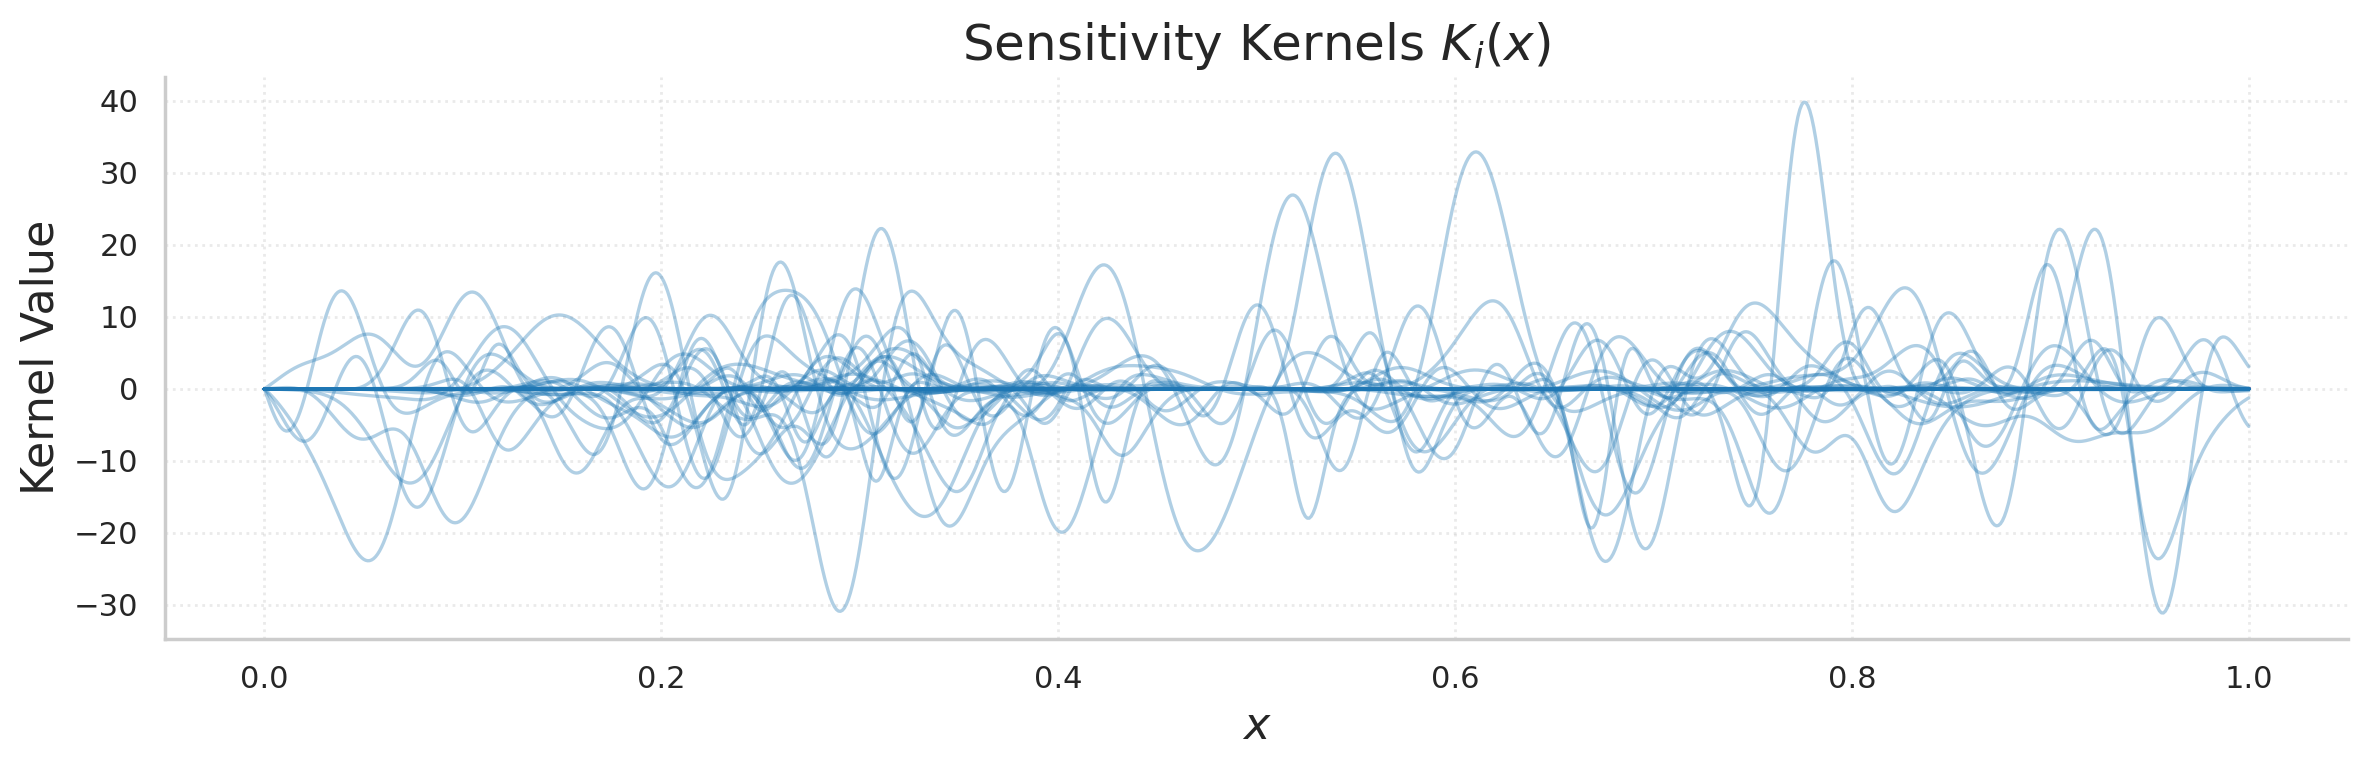

In [113]:
# Visualization: Sensitivity Kernels
x = np.linspace(function_domain.a, function_domain.b, 1000)

fig_title = "Sensitivity Kernels"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 4), dpi=200)
for i in range(N_d):
    plt.plot(x, G.get_kernel(i).evaluate(x), color='tab:blue', alpha=0.35, linewidth=1.2)

plt.title(r"Sensitivity Kernels $K_i(x)$", fontsize=18)
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel("Kernel Value", fontsize=16)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

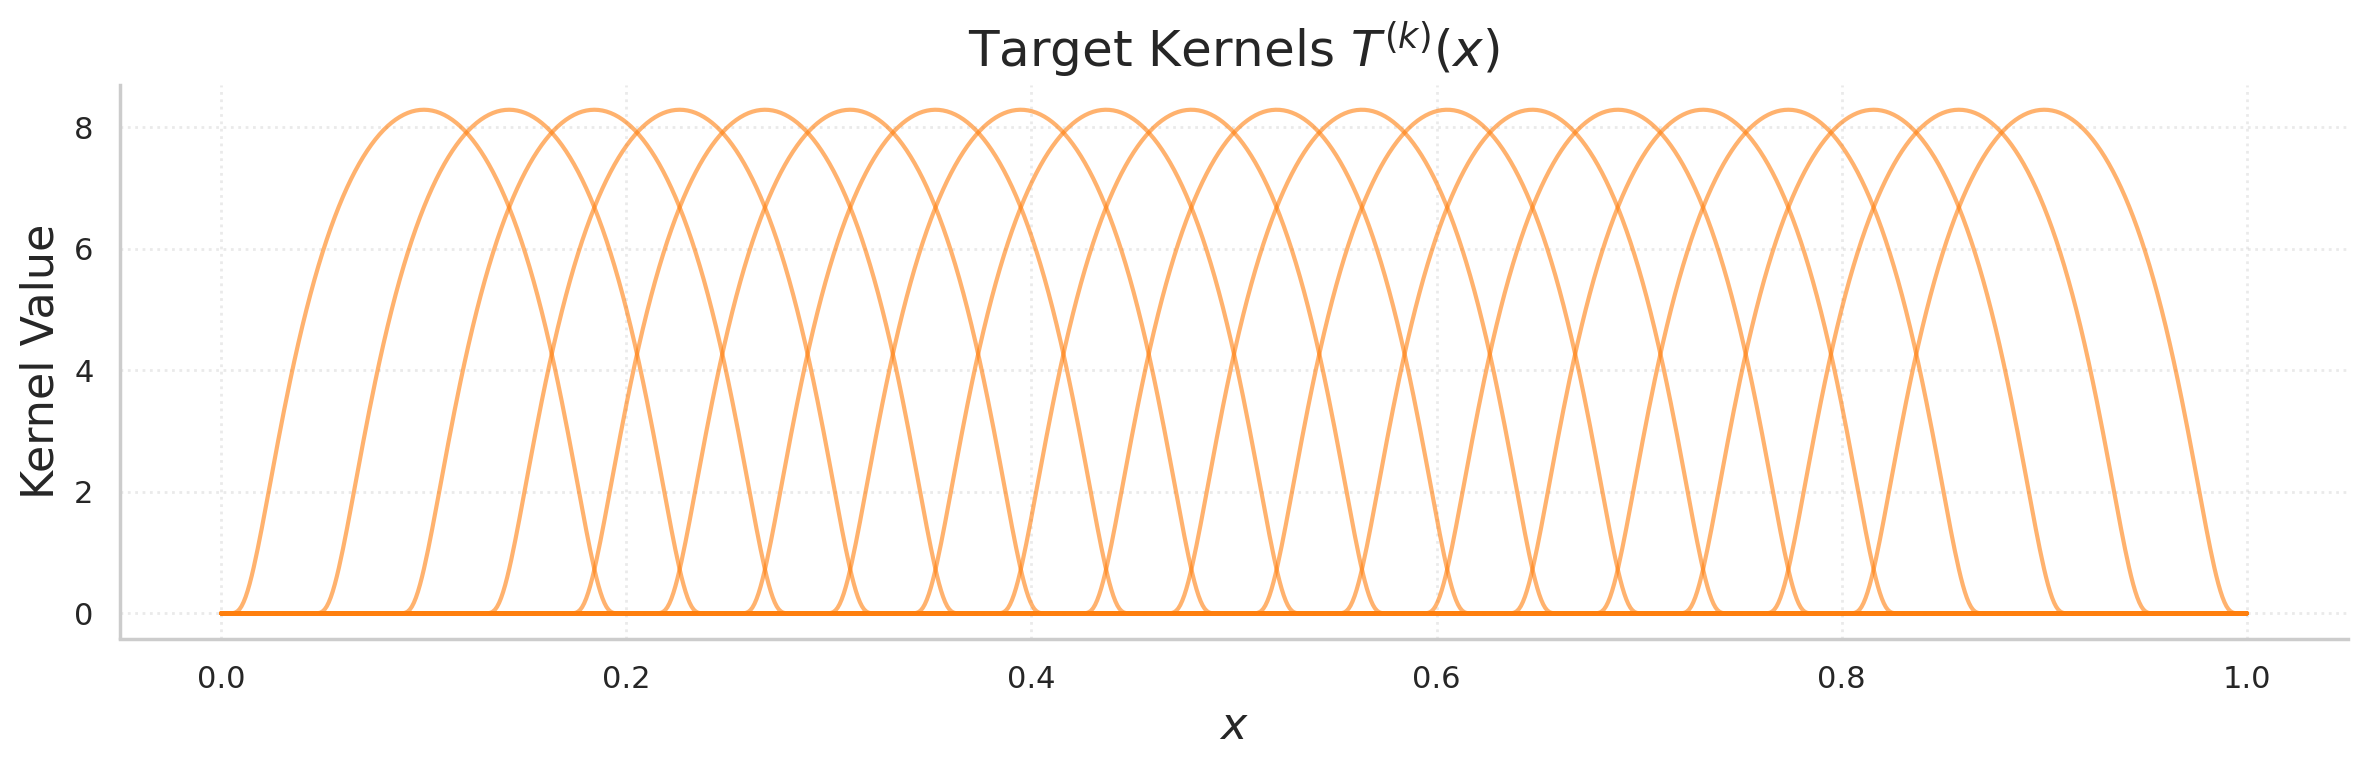

In [114]:
# Visualization: Target Kernels
fig_title = "Target Kernels"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 4), dpi=200)
for i in range(N_p):
    plt.plot(x, T.get_kernel(i).evaluate(x), color='tab:orange', alpha=0.6, linewidth=1.5)

plt.title(r"Target Kernels $T^{(k)}(x)$", fontsize=18)
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel("Kernel Value", fontsize=16)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

# Part 2: Behind the Scenes (Hidden from the "User")

This section simulates what happens when someone prepares a SOLA problem for another person.
The "experimenter" knows the true model, but the "analyst" only receives:
- The operators $G$ and $T$
- The noisy data $\tilde{d}$
- The data covariance $C_D$

**The twist**: We will construct a *pathological* true model that:
1. Produces the exact same observed data as a "normal" true model
2. Has vastly different true properties

This demonstrates that SOLA can fail when the true model doesn't have small norm.

In [115]:
# Step 1: Create a "normal" true model with small norm
m_normal = Function(M, evaluate_callable=lambda x:
    np.exp(-((x - function_domain.center)/0.5)**2) * np.sin(5 * np.pi * x) + x)

# Compute the true data from the normal model
d_bar = G(m_normal)

# Add noise to create the observed data
noise_level = 0.1 * np.max(np.abs(d_bar))
np.random.seed(42)
d_tilde = d_bar + np.random.normal(0, noise_level, d_bar.shape)

# Compute the "normal" true properties
p_normal = T(m_normal)

print(f"Normal true model norm: {M.norm(m_normal):.4f}")
print(f"Normal true properties: min={np.min(p_normal):.4f}, max={np.max(p_normal):.4f}")

Normal true model norm: 0.8237
Normal true properties: min=-0.3813, max=1.3318


In [116]:
# Step 2: Construct a PATHOLOGICAL true model
# This model fits the SAME OBSERVED DATA but has OPPOSITE properties!
# We constrain against d_tilde (the noisy observation), not d_bar, because in a
# real inversion the noise-free d_bar is never available -- only d_tilde is.

# Create the joint operator [G; T]
G_T = ColumnLinearOperator([G, T])

# Target properties: the NEGATIVE of the normal true properties
p_pathological_target = -p_normal

# Form the joint "constraint" vector: fit the OBSERVED data AND the pathological properties
d_constraint = [d_tilde, p_pathological_target]

# Find the minimum norm model that satisfies both constraints
solver = CholeskySolver(galerkin=False, parallel=True, n_jobs=12)
W_hat_inv = solver(G_T @ G_T.adjoint)
m_pathological = (G_T.adjoint @ W_hat_inv)(d_constraint)

# Verify the pathological model
print("Pathological model verification:")
print(f"  Data fit error (vs. observed d_tilde): {np.linalg.norm(G(m_pathological) - d_tilde):.2e}")
print(f"  Residual vs. noise-free d_bar (unknown in practice): {np.linalg.norm(G(m_pathological) - d_bar):.4f}  (~ noise level)")
print(f"  Property fit error: {np.linalg.norm(T(m_pathological) - p_pathological_target):.2e}")
print(f"  Pathological model norm: {M.norm(m_pathological):.4f}")
print(f"\nThe pathological model has norm {M.norm(m_pathological)/M.norm(m_normal):.1f}x larger than the normal model!")

Pathological model verification:
  Data fit error (vs. observed d_tilde): 2.89e-04
  Residual vs. noise-free d_bar (unknown in practice): 0.9896  (~ noise level)
  Property fit error: 2.42e-01
  Pathological model norm: 105661.6764

The pathological model has norm 128273.7x larger than the normal model!


In [117]:
# Step 3: Store the TRUE properties (from the pathological model)
# This is what the "analyst" doesn't know!
p_true = T(m_pathological)  # These are the actual true properties
m_true = m_pathological     # This is the actual true model

print("The 'analyst' will receive:")
print(f"  - Operators G, T")
print(f"  - Noisy data d̃ (based on d_bar from pathological model)")
print(f"  - Data covariance C_D")
print("\nThey do NOT know:")
print(f"  - The true model m_true")
print(f"  - The true properties p_true = T(m_true)")

The 'analyst' will receive:
  - Operators G, T
  - Noisy data d̃ (based on d_bar from pathological model)
  - Data covariance C_D

They do NOT know:
  - The true model m_true
  - The true properties p_true = T(m_true)


# Part 3: The Analyst's Perspective (Standard SOLA Application)

From here on, we simulate what the "analyst" sees. They receive:
- Forward operator $G$
- Target operator $T$
- Noisy observations $\tilde{d}$
- Data covariance $C_D$

They do NOT know the true model or its properties. They will apply SOLA in the standard way.

In [118]:
# Define the data noise covariance (known to the analyst)
noise_variance = noise_level**2
C_D_matrix = noise_variance * np.eye(N_d)

# Create data noise measure for SOLA
gaussian_D_noise = GaussianMeasure.from_covariance_matrix(D, C_D_matrix, expectation=np.zeros(N_d))

# Create data measure with observed data mean
gaussian_D = GaussianMeasure.from_covariance_matrix(D, C_D_matrix, expectation=d_tilde)

print("Data uncertainty model:")
print(f"  Noise standard deviation: {np.sqrt(noise_variance):.4f}")
print(f"  Relative noise level: {100 * np.sqrt(noise_variance) / np.max(np.abs(d_tilde)):.1f}%")

Data uncertainty model:
  Noise standard deviation: 0.1088
  Relative noise level: 9.8%


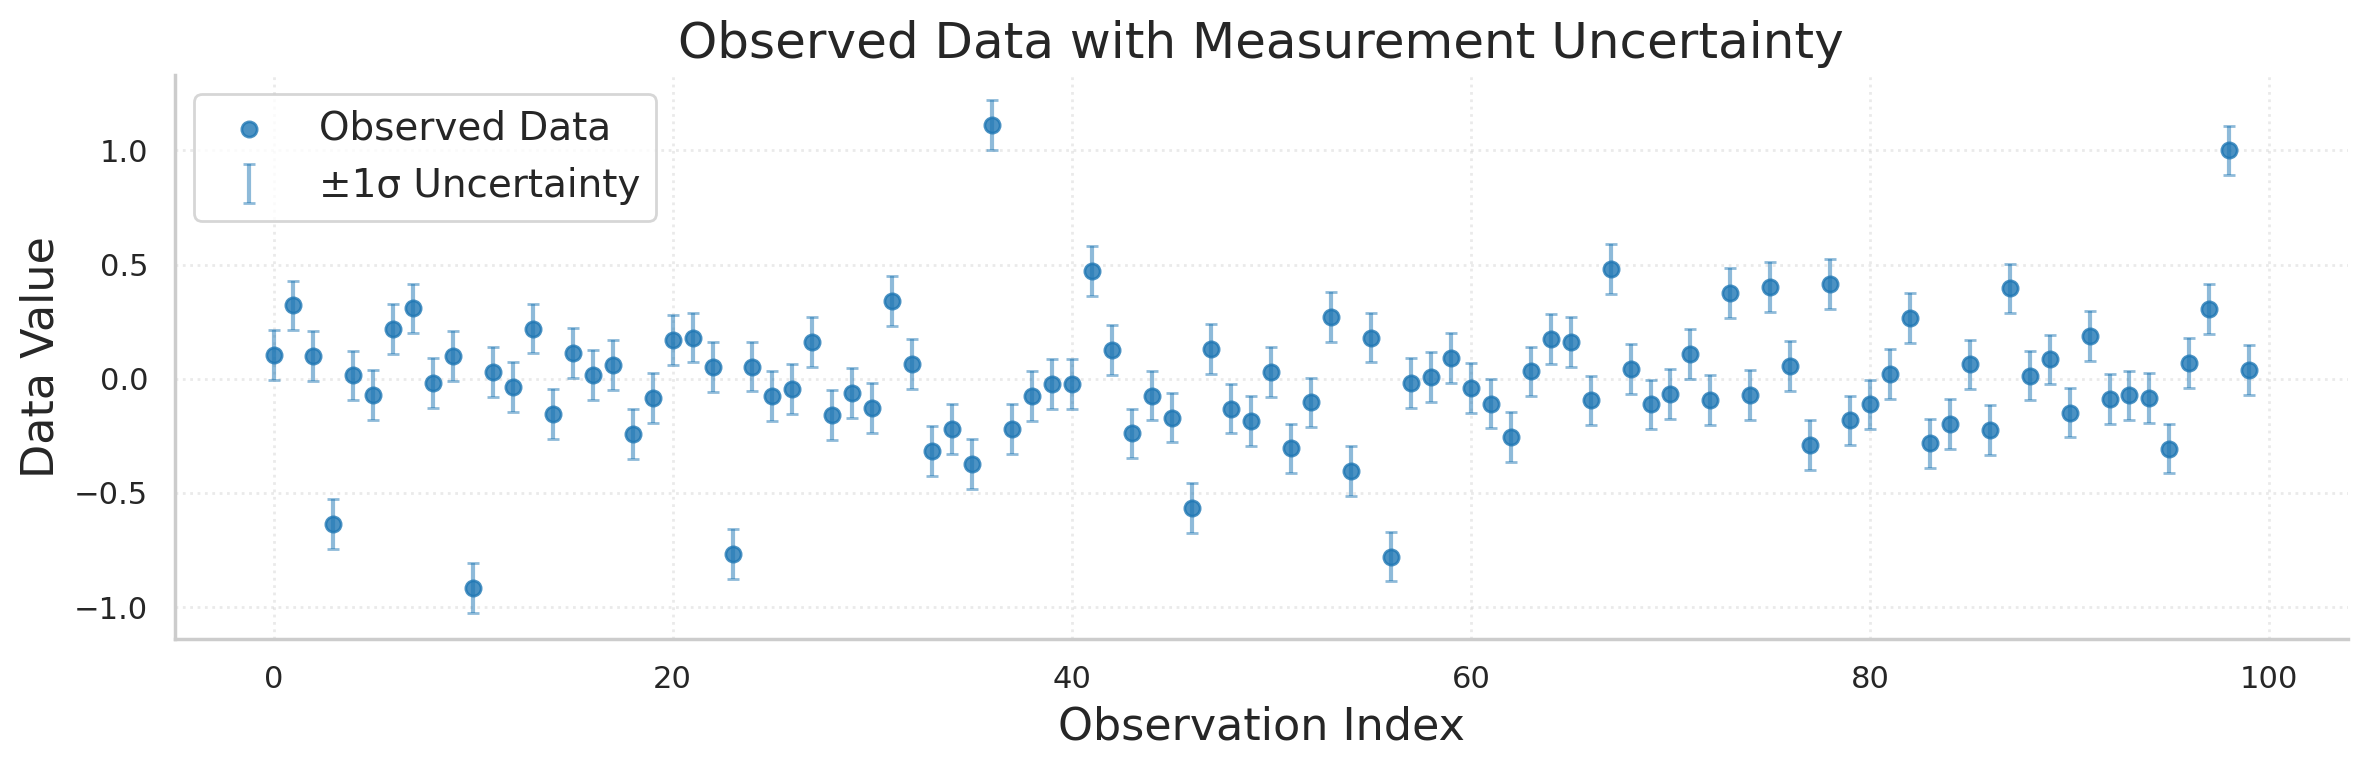

In [119]:
# Visualize the observed data with uncertainty
fig_title = "Observed Data"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 4), dpi=200)
data_indices = np.arange(len(d_tilde))
std_values = np.sqrt(noise_variance)

plt.scatter(data_indices, d_tilde, label='Observed Data', color='tab:blue', alpha=0.8, s=30)
plt.errorbar(data_indices, d_tilde, yerr=std_values, fmt='none',
            color='tab:blue', alpha=0.5, capsize=2, capthick=1, label='±1σ Uncertainty')

plt.title("Observed Data with Measurement Uncertainty", fontsize=18)
plt.xlabel('Observation Index', fontsize=16)
plt.ylabel('Data Value', fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

In [120]:
# Compute SOLA operator components
print("Computing SOLA operator...")

# Step 1: Compute normal operator Λ = GG*
print("  - Computing Gram matrix Λ = GG*...")
Lambda = G @ G.adjoint

# Step 2: Solve (Λ + C_D)^{-1}
print("  - Computing regularized inverse W⁻¹ = (Λ + C_D)⁻¹...")
cholesky_solver = CholeskySolver(galerkin=False, parallel=True, n_jobs=12)
W_inv = cholesky_solver(Lambda + gaussian_D.covariance)

# Step 3: Compute generalized inverse G† = G* W^{-1}
print("  - Computing generalized inverse G† = G*W⁻¹...")
G_inv = G.adjoint @ W_inv
G_inv_pure = G.adjoint @ cholesky_solver(Lambda)

print("✓ SOLA operator components computed!")

Computing SOLA operator...
  - Computing Gram matrix Λ = GG*...
  - Computing regularized inverse W⁻¹ = (Λ + C_D)⁻¹...
  - Computing generalized inverse G† = G*W⁻¹...
✓ SOLA operator components computed!


In [121]:
# Compute SOLA property operator X = T G†
print("Computing SOLA property operator X = TG†...")
X = T @ G_inv

# Apply unimodularity constraint
print("Applying unimodularity constraint...")

# Create constant unit function
M_one = Function(M, evaluate_callable=lambda x: np.ones_like(x))
v = G(M_one)
w = np.ones(N_p)
u = W_inv(v)
beta = D.inner_product(v, u)
correction = LinearOperator.from_matrix(D, P, np.outer((X(v) - w) / beta, u))
X_unimodular = X - correction

print(f"Unimodularity check: X_uni(G(1)) = {X_unimodular(v)}")
print("✓ Unimodular SOLA operator ready!")

Computing SOLA property operator X = TG†...
Applying unimodularity constraint...
Unimodularity check: X_uni(G(1)) = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
✓ Unimodular SOLA operator ready!


In [122]:
# Apply SOLA to get property estimates with uncertainty
property_measure = gaussian_D.affine_mapping(operator=X_unimodular)

# Extract mean and standard deviation
p_sola = property_measure.expectation
P_cov_mat = property_measure.covariance.matrix(dense=True, parallel=True, n_jobs=8)
p_std = np.sqrt(np.diag(P_cov_mat))

print("SOLA property estimation complete!")
print(f"  Property estimates: min={np.min(p_sola):.4f}, max={np.max(p_sola):.4f}")
print(f"  Average uncertainty (1σ): {np.mean(p_std):.4f}")

SOLA property estimation complete!
  Property estimates: min=-0.3846, max=1.3971
  Average uncertainty (1σ): 0.1564


# Part 4: SOLA Results (What the Analyst Sees)

The analyst now has property estimates with uncertainty quantification.
They can visualize their results, but they don't know the true properties to compare against.

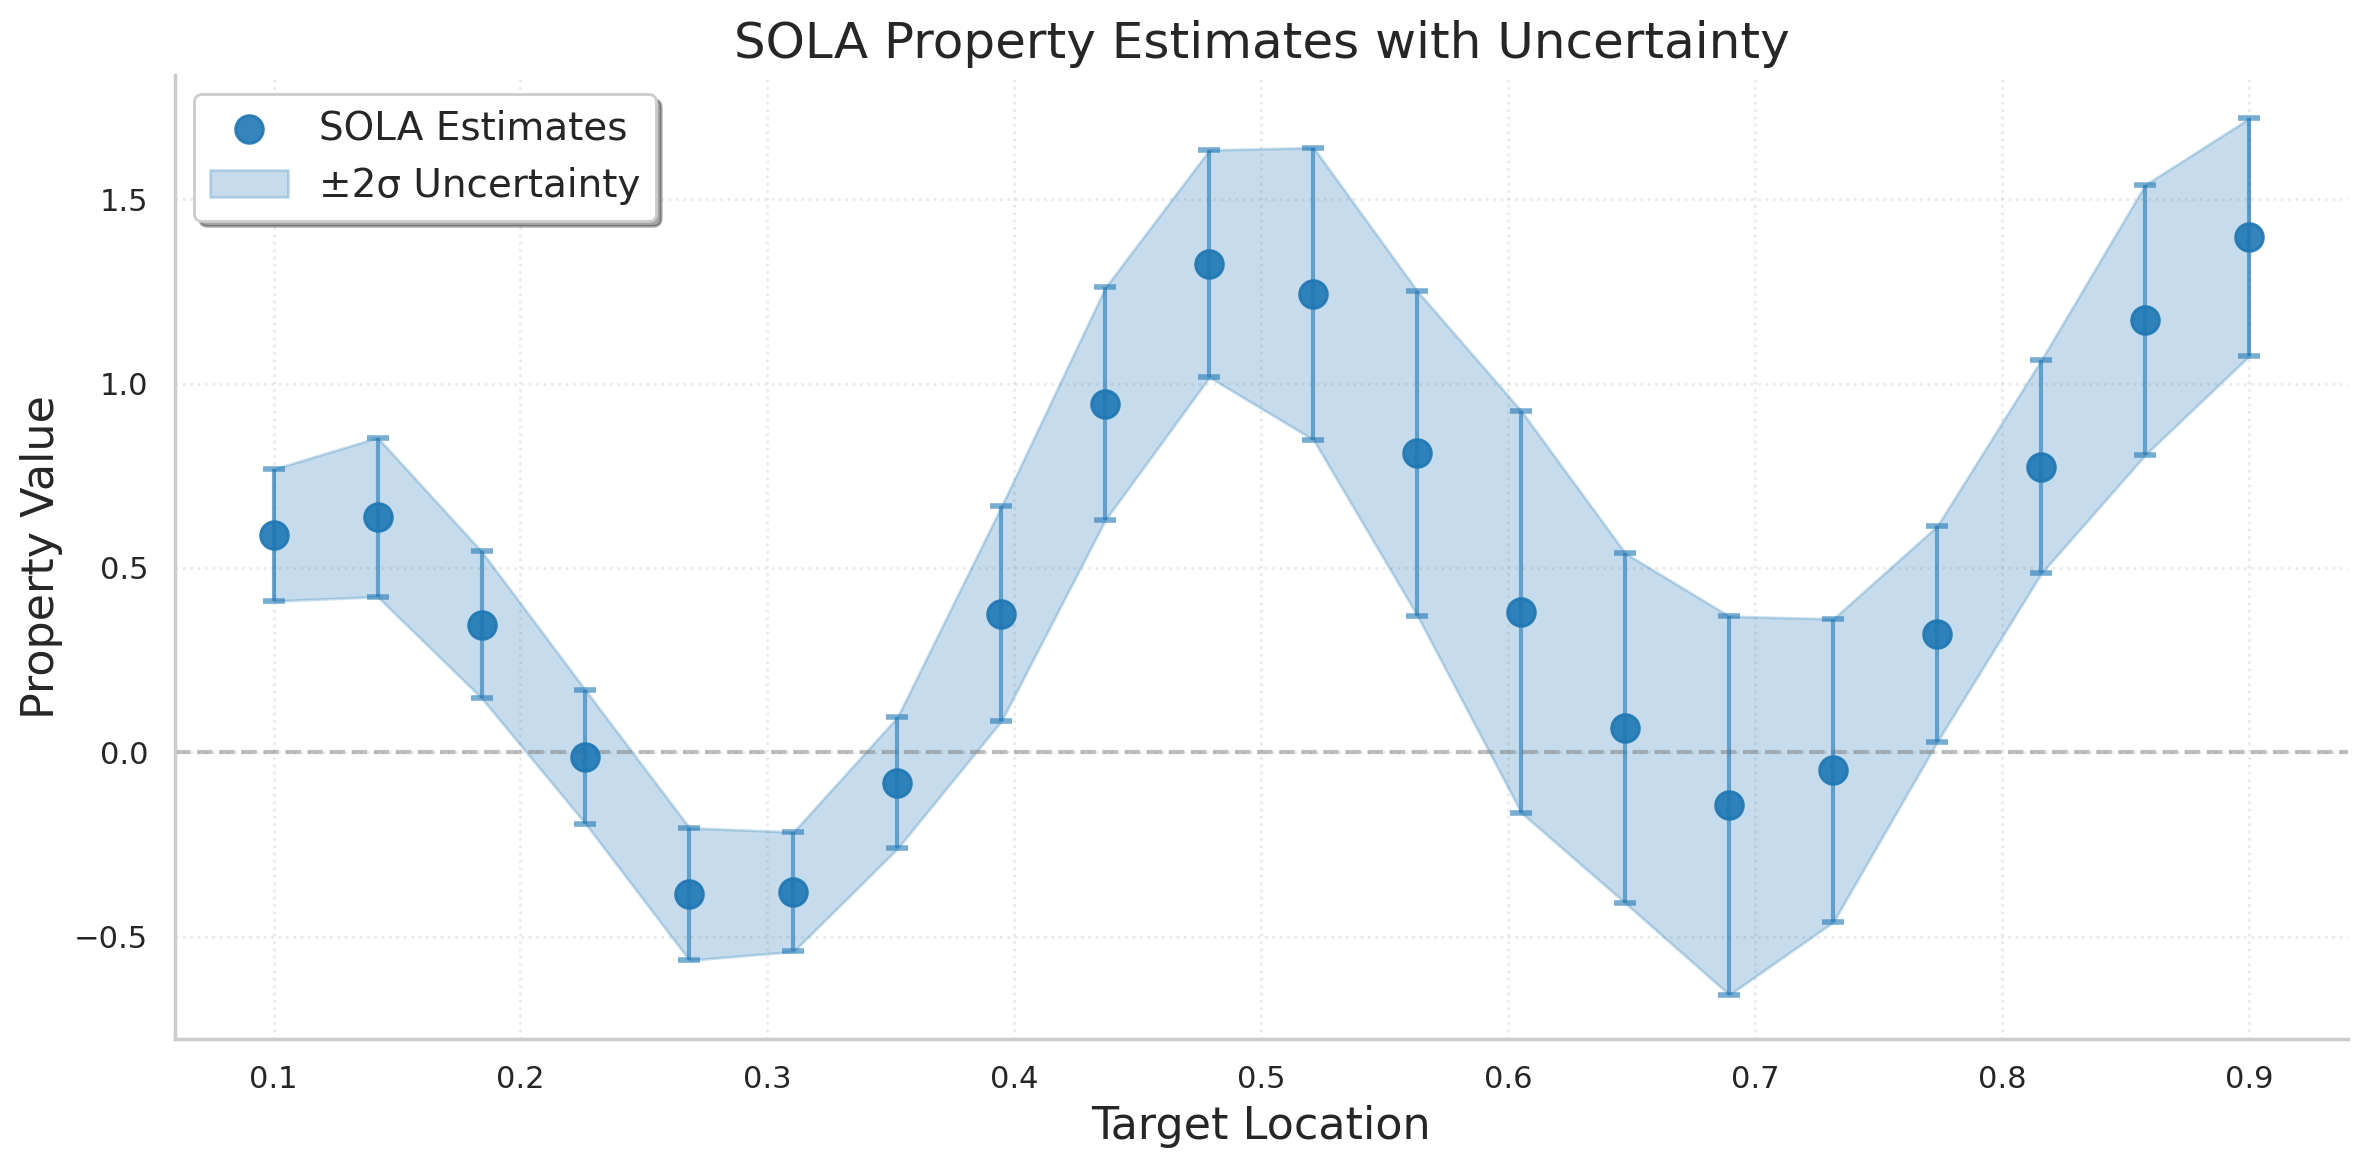


The analyst is satisfied - they have property estimates with uncertainty!
But are these estimates actually correct? They have no way to know...


In [123]:
# Visualize SOLA property estimates (analyst's view - no true values shown)
fig_title = "SOLA Property Estimates"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 6), dpi=200)

plt.scatter(centers, p_sola, label='SOLA Estimates',
           color='tab:blue', marker='o', s=100, alpha=0.9, zorder=5)
plt.fill_between(centers, p_sola - 2*p_std, p_sola + 2*p_std,
                alpha=0.25, color='tab:blue', label='±2σ Uncertainty', zorder=1)
plt.errorbar(centers, p_sola, yerr=2*p_std, fmt='none',
            ecolor='tab:blue', alpha=0.6, capsize=4, capthick=2, zorder=3)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('SOLA Property Estimates with Uncertainty', fontsize=18)
plt.xlabel('Target Location', fontsize=16)
plt.ylabel('Property Value', fontsize=16)
plt.legend(fontsize=14, frameon=True, fancybox=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

print("\nThe analyst is satisfied - they have property estimates with uncertainty!")
print("But are these estimates actually correct? They have no way to know...")

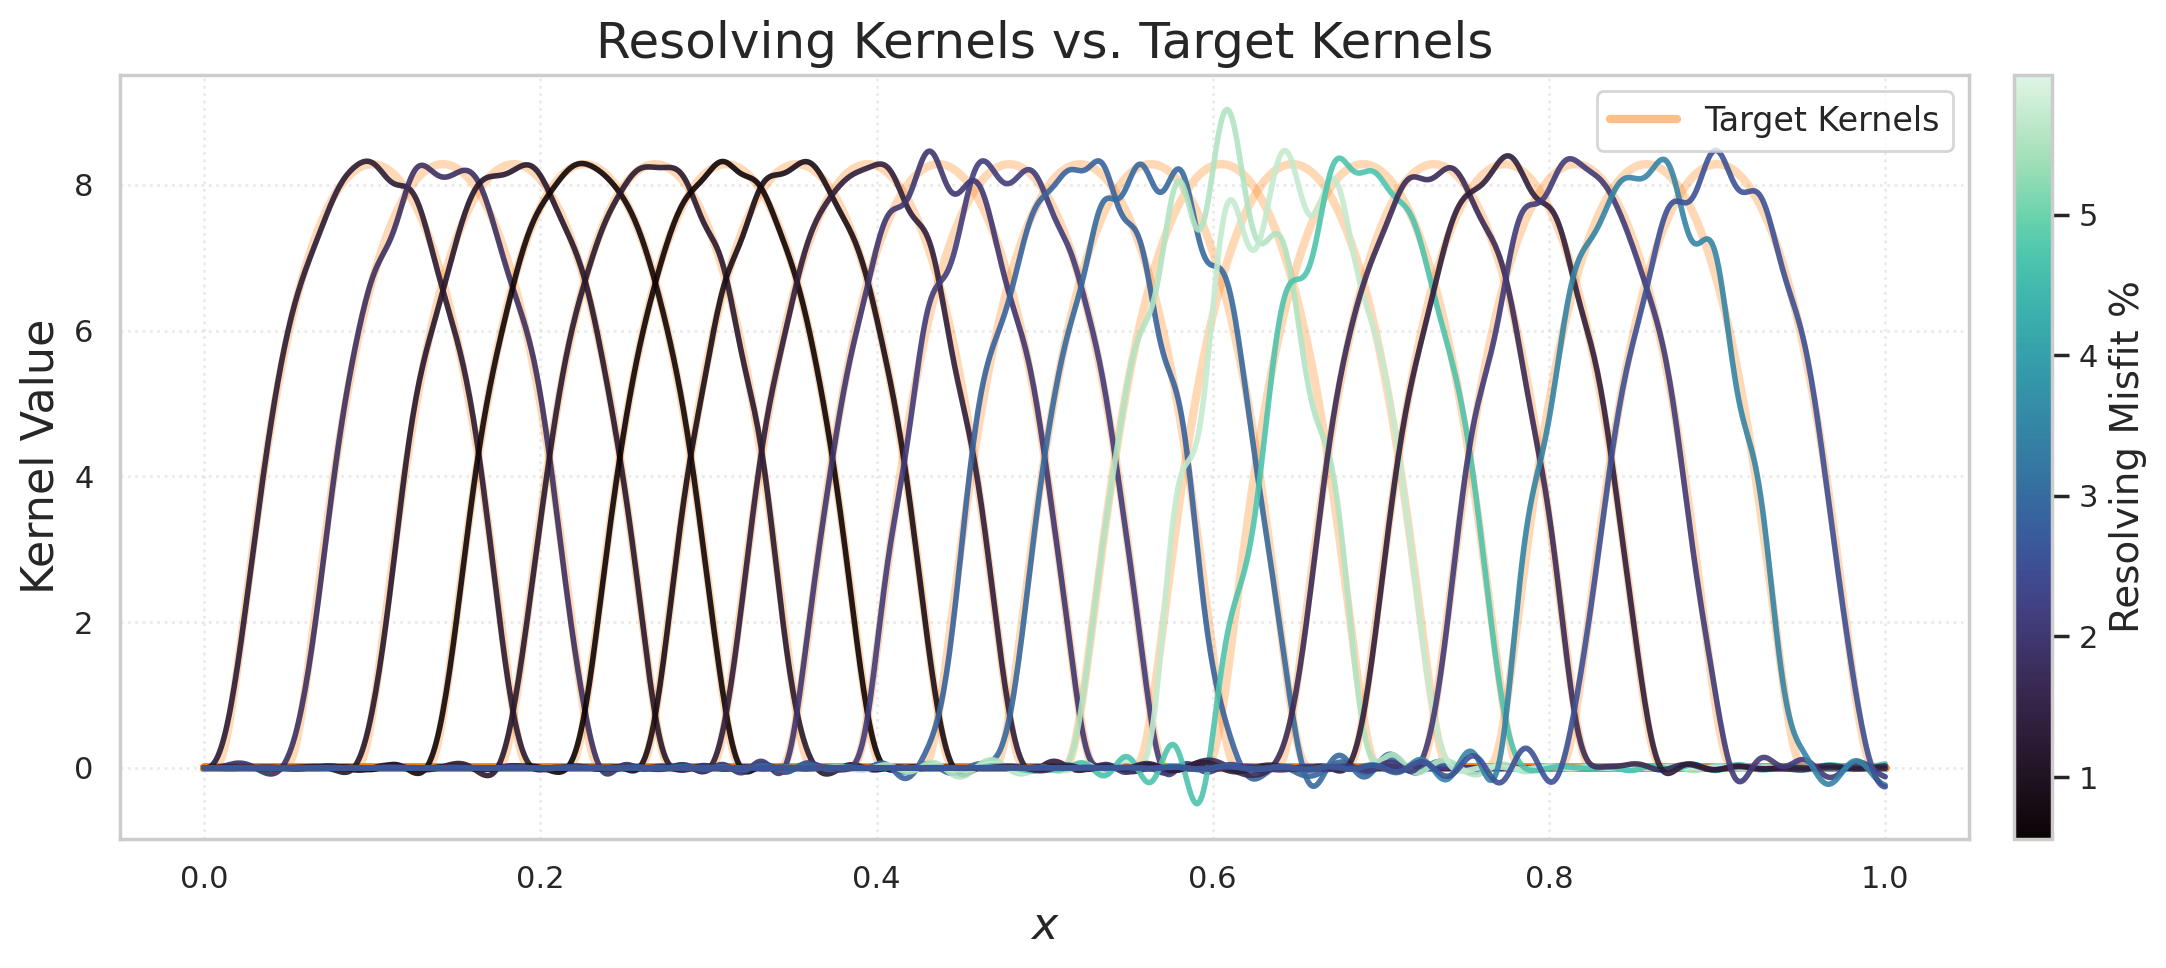


Resolving kernel quality:
  Average misfit: 2.3%
  Max misfit: 5.7%

The resolving kernels match the target kernels quite well!
This suggests SOLA should work... but will it?


In [124]:
# Visualize resolving kernels vs target kernels
# The analyst can check how well the resolving kernels match the targets
from matplotlib import cm

A_adjoint = (X @ G).adjoint

cp = np.zeros(N_p)
resolving_misfits = np.zeros(N_p)

# Compute all resolving residuals first for normalization
for i in range(N_p):
    cp[i] = 1
    A_i = A_adjoint(cp)
    target_kernel = T.get_kernel(i)
    resolving_misfits[i] = M.norm(A_i - target_kernel) / M.norm(target_kernel)
    cp[i] = 0

# Convert misfits to percent for visualization
resolving_misfits_percent = 100 * resolving_misfits

# Normalize colormap to the actual range of misfits (with a small margin)
vmin = resolving_misfits_percent.min() * 0.95
vmax = resolving_misfits_percent.max() * 1.05
norm = plt.Normalize(vmin, vmax)
cmap = plt.colormaps.get_cmap("mako")

fig, ax = plt.subplots(figsize=(12, 5), dpi=200)

# First, plot target kernels in the background (light orange)
for i in range(N_p):
    target_kernel = T.get_kernel(i)
    ax.plot(x, target_kernel.evaluate(x), color='tab:orange', alpha=0.3,
            linewidth=3, linestyle='-', zorder=1)

# Then, plot resolving kernels on top (colored by misfit)
for i in range(N_p):
    cp[i] = 1
    A_i = A_adjoint(cp)
    color = cmap(norm(resolving_misfits_percent[i]))
    ax.plot(x, A_i.evaluate(x), alpha=0.9, linewidth=2, color=color, zorder=2)
    cp[i] = 0

# Add a dummy line for the legend
ax.plot([], [], color='tab:orange', alpha=0.5, linewidth=3, label='Target Kernels')

ax.set_title("Resolving Kernels vs. Target Kernels", fontsize=18)
ax.set_xlabel(r"$x$", fontsize=16)
ax.set_ylabel("Kernel Value", fontsize=16)
ax.legend(fontsize=12, loc='upper right')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Resolving Misfit %", fontsize=14)

ax.grid(True, linestyle=':', alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(figures_folder, "resolving_kernels.png"), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(figures_folder, "resolving_kernels.pdf"), bbox_inches='tight')
plt.show()

print(f"\nResolving kernel quality:")
print(f"  Average misfit: {np.mean(resolving_misfits_percent):.1f}%")
print(f"  Max misfit: {np.max(resolving_misfits_percent):.1f}%")
print(f"\nThe resolving kernels match the target kernels quite well!")
print("This suggests SOLA should work... but will it?")

# Part 5: The Reveal - SOLA Has Failed!

Now we reveal what the analyst doesn't know: the TRUE properties of the actual true model.
We will see that SOLA's estimates are completely wrong - not just slightly off, but
in complete contradiction with the truth!

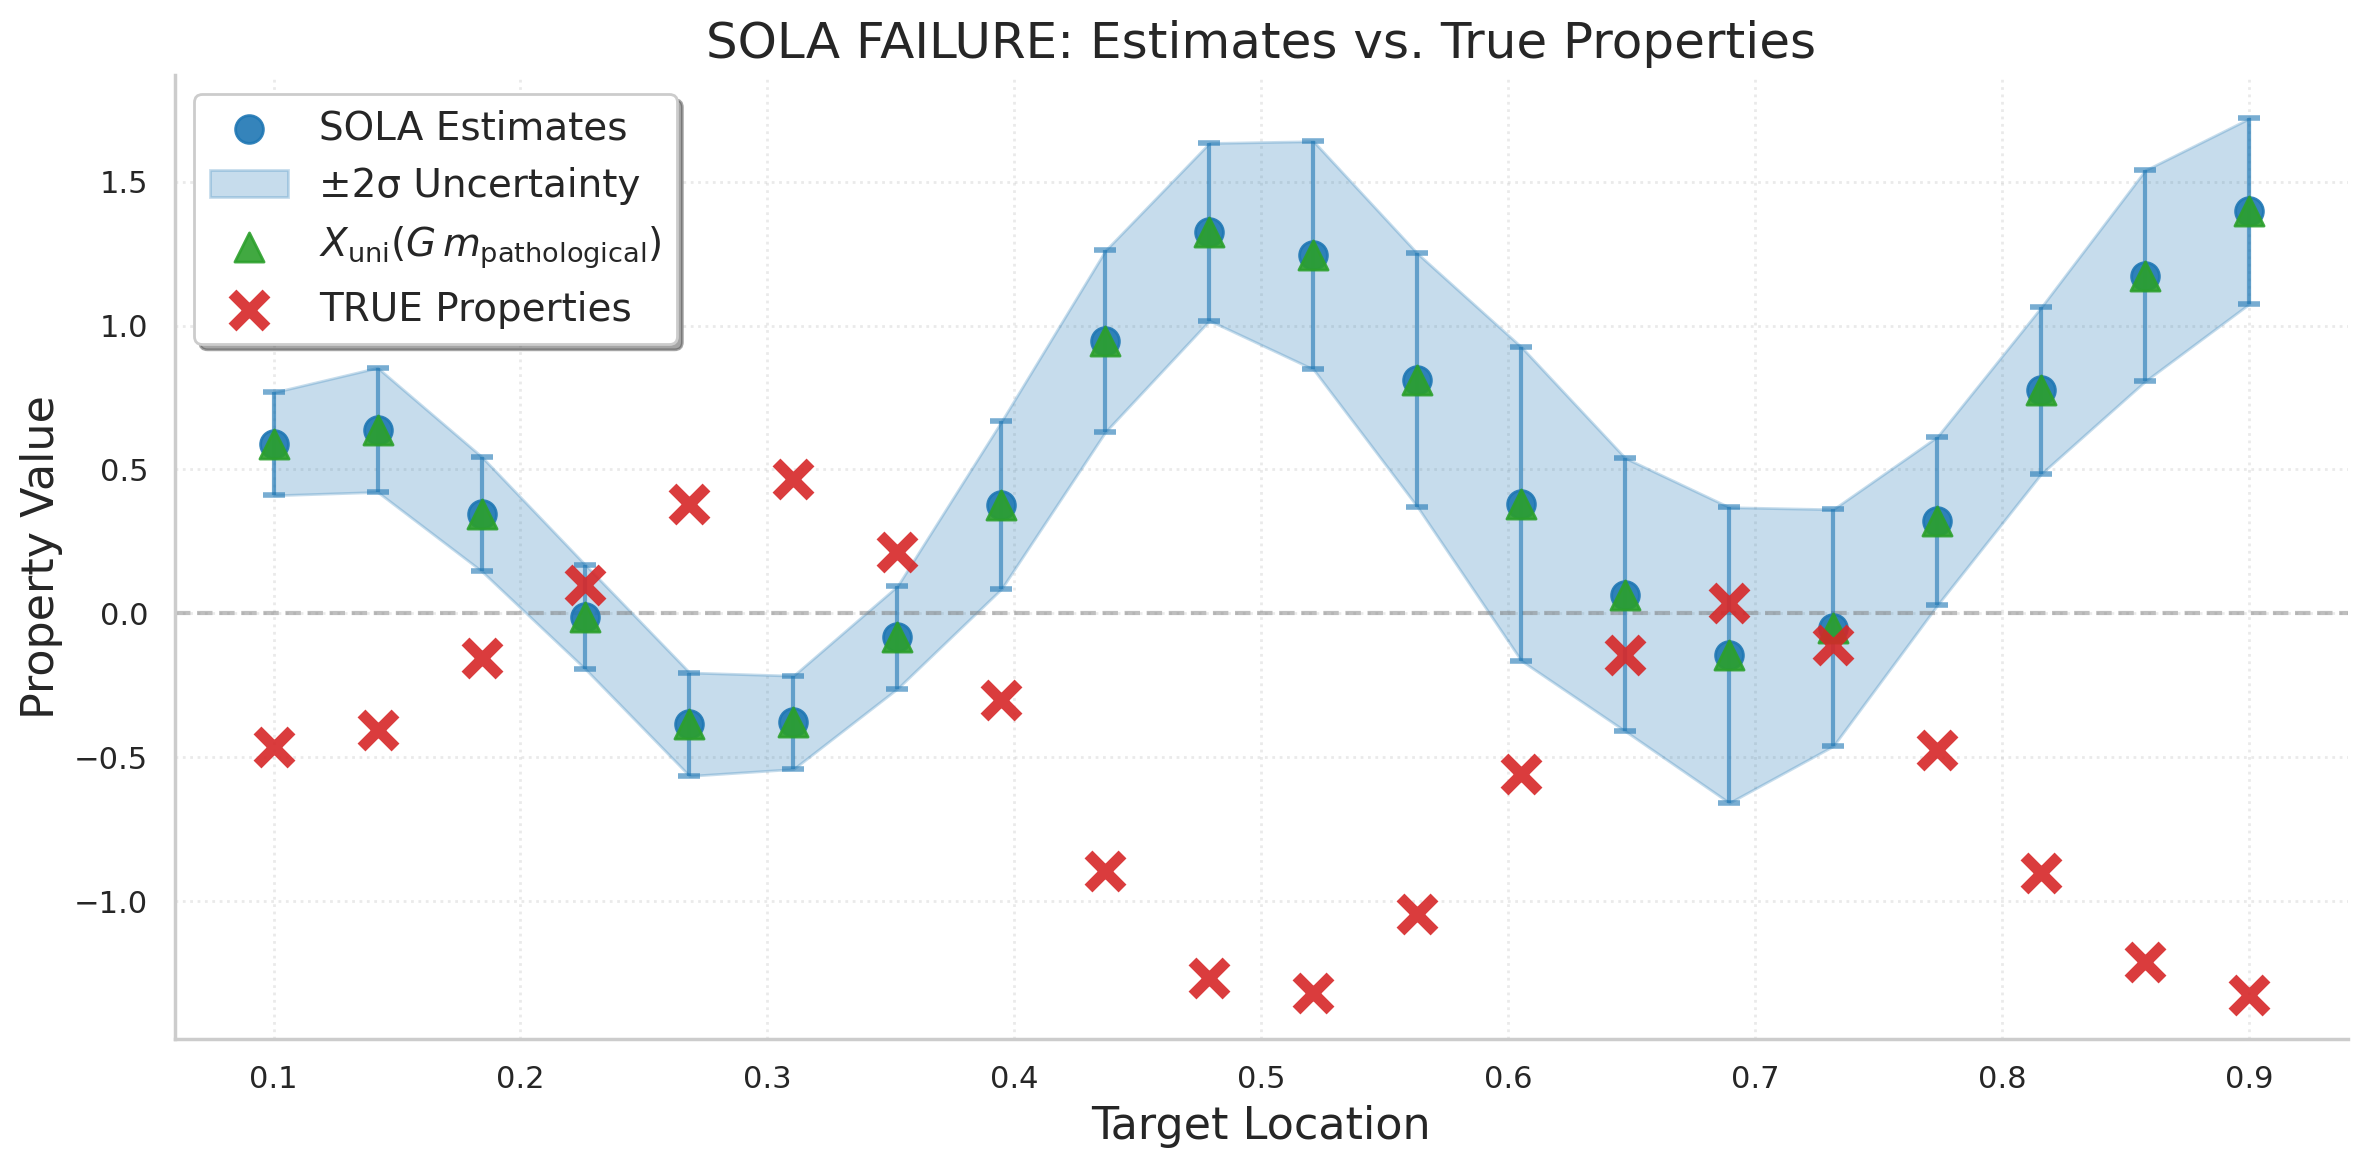


SOLA FAILURE ANALYSIS
Properties within ±2σ: 4/20 (20.0%)
  Expected for valid inference: ~95%

Mean absolute error: 1.1554
RMS error: 1.4476
Max error: 2.7213
Average uncertainty (2σ): 0.3129

Error/Uncertainty ratio: 7.4x

||X_uni(G m_pathological) - p_sola|| = 5.63e-05  (near machine/solver precision: both are now computed from the same observed data d_tilde)
This confirms the pathological model reproduces SOLA's exact output computed
from the real observed data -- it is not an artifact of a different data vector.

⚠️  SOLA has catastrophically failed!
The estimates are not just wrong, they are in the OPPOSITE direction!


In [125]:
# REVEAL: Compare SOLA estimates with the TRUE properties
fig_title = "SOLA Failure Revealed"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

# Push the pathological model's OWN data through the (unimodular) SOLA operator.
# m_pathological was built to fit d_tilde (the OBSERVED data) directly, so
# G(m_pathological) ~ d_tilde and this should coincide with p_sola = X_unimodular(d_tilde)
# up to solver tolerance -- confirming the pathological model reproduces the exact
# SOLA output an analyst would compute from the real observed data.
p_xg_pathological = X_unimodular(G(m_pathological))

plt.figure(figsize=(12, 6), dpi=200)

# Plot SOLA estimates
plt.scatter(centers, p_sola, label='SOLA Estimates',
           color='tab:blue', marker='o', s=100, alpha=0.9, zorder=5)
plt.fill_between(centers, p_sola - 2*p_std, p_sola + 2*p_std,
                alpha=0.25, color='tab:blue', label='±2σ Uncertainty', zorder=1)
plt.errorbar(centers, p_sola, yerr=2*p_std, fmt='none',
            ecolor='tab:blue', alpha=0.6, capsize=4, capthick=2, zorder=3)

# Plot X_unimodular(G(m_pathological)) -- the SOLA operator applied to the
# pathological model's own data (fit to the same observed d_tilde)
plt.scatter(centers, p_xg_pathological, label=r'$X_{\mathrm{uni}}(G\,m_{\mathrm{pathological}})$',
           color='tab:green', marker='^', s=110, alpha=0.9, zorder=6)

# Plot TRUE properties (THE REVEAL!)
plt.scatter(centers, p_true, label='TRUE Properties',
           color='tab:red', marker='x', s=150, alpha=0.9, linewidths=4, zorder=10)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('SOLA FAILURE: Estimates vs. True Properties', fontsize=18)
plt.xlabel('Target Location', fontsize=16)
plt.ylabel('Property Value', fontsize=16)
plt.legend(fontsize=14, frameon=True, fancybox=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

# Quantitative assessment of the failure
property_errors = np.abs(p_sola - p_true)
within_2sigma = np.sum(property_errors <= 2*p_std)

print("\n" + "="*60)
print("SOLA FAILURE ANALYSIS")
print("="*60)
print(f"Properties within ±2σ: {within_2sigma}/{len(p_true)} ({100*within_2sigma/len(p_true):.1f}%)")
print(f"  Expected for valid inference: ~95%")
print(f"\nMean absolute error: {np.mean(property_errors):.4f}")
print(f"RMS error: {np.sqrt(np.mean(property_errors**2)):.4f}")
print(f"Max error: {np.max(property_errors):.4f}")
print(f"Average uncertainty (2σ): {np.mean(2*p_std):.4f}")
print(f"\nError/Uncertainty ratio: {np.mean(property_errors)/np.mean(p_std):.1f}x")
print("="*60)
print(f"\n||X_uni(G m_pathological) - p_sola|| = {np.linalg.norm(p_xg_pathological - p_sola):.2e}  "
      f"(near machine/solver precision: both are now computed from the same observed data d_tilde)")
print("This confirms the pathological model reproduces SOLA's exact output computed")
print("from the real observed data -- it is not an artifact of a different data vector.")
print("\n⚠️  SOLA has catastrophically failed!")
print("The estimates are not just wrong, they are in the OPPOSITE direction!")

### The Pathological Model, On Its Own

Before rushing to the next argument, let's just look at what `m_pathological` actually
looks like -- not overlaid with anything else, just by itself.

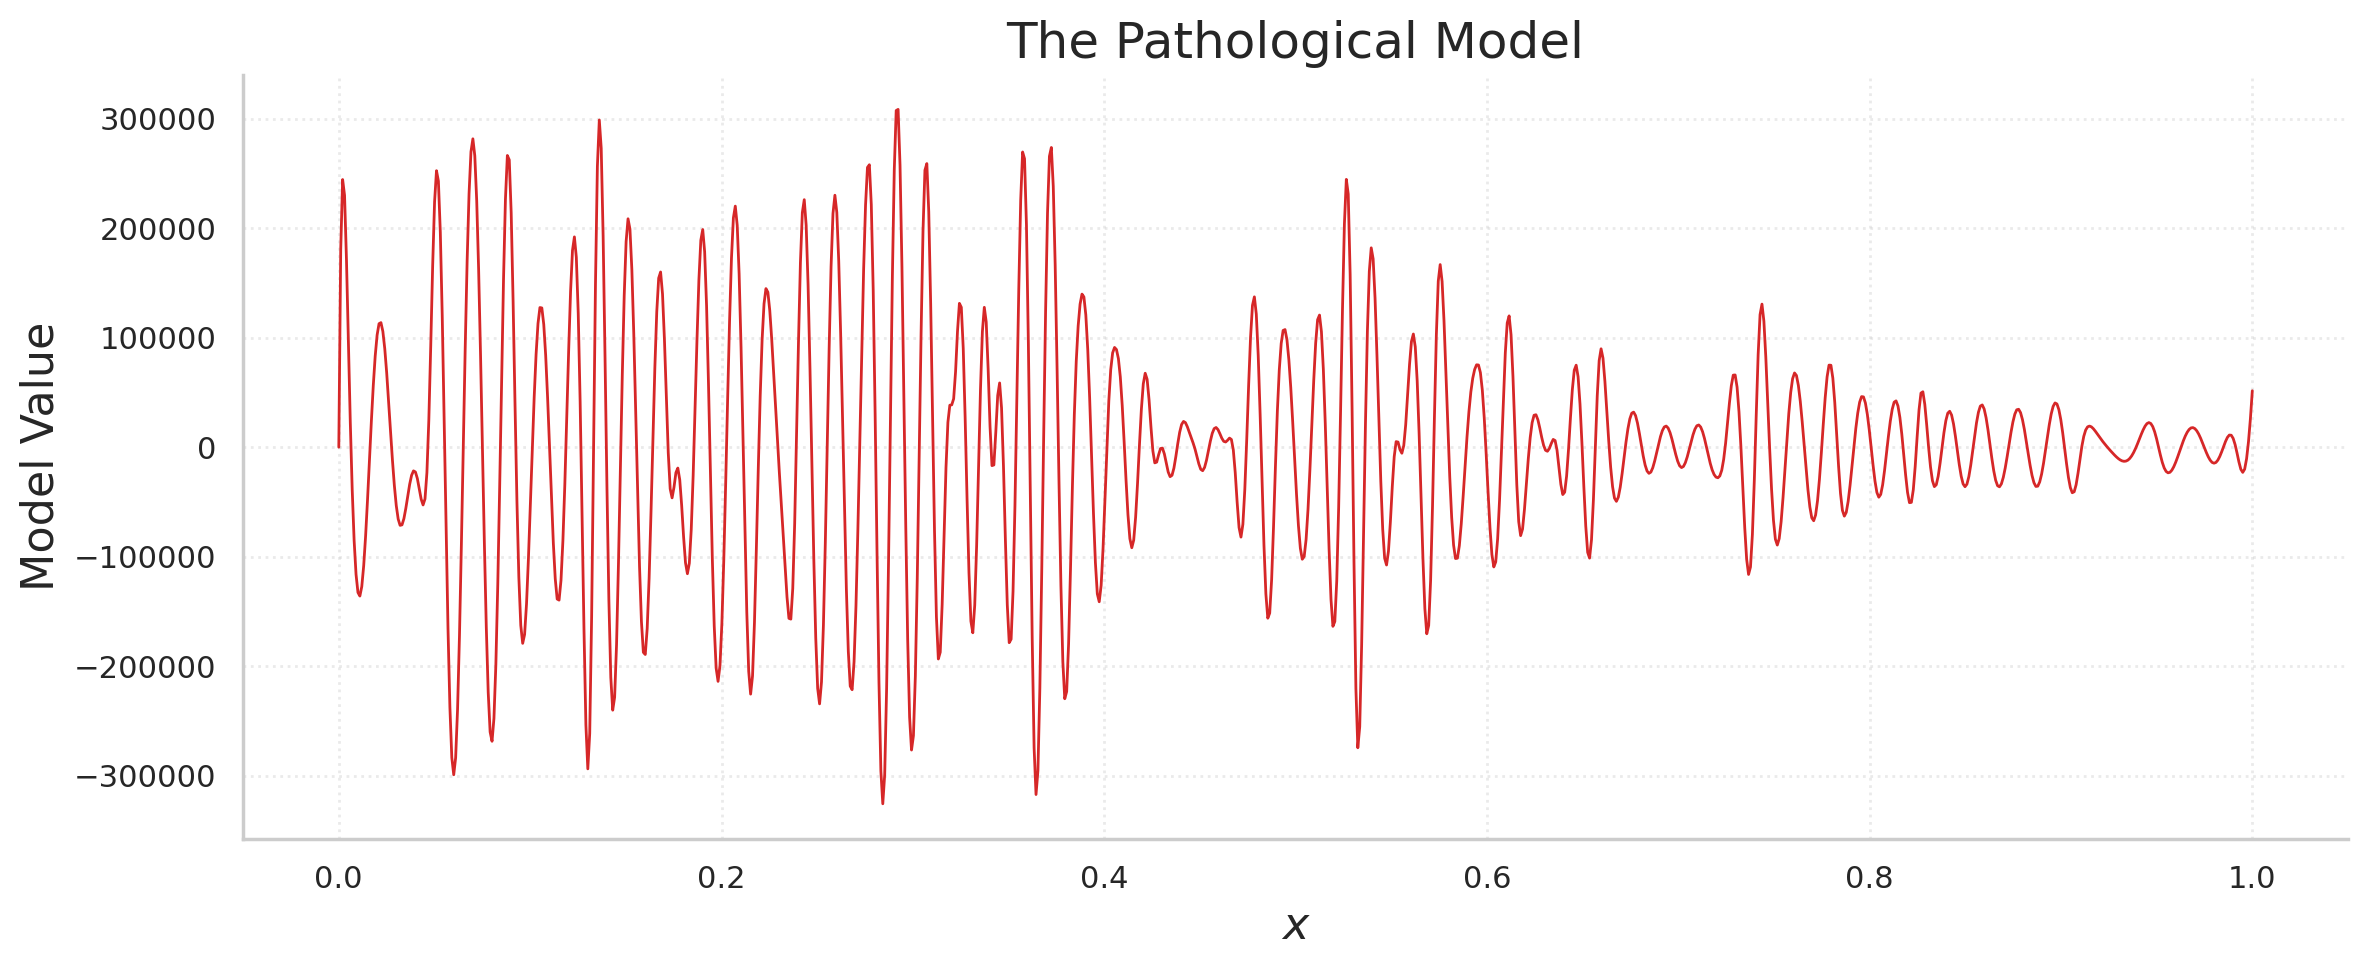

||m_pathological|| = 105661.7
||m_normal||       = 0.8237
Ratio: 128274x larger than the 'normal' true model


In [126]:
fig_title = "Pathological Model Alone"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 5), dpi=200)
plt.plot(x, m_pathological.evaluate(x), color='tab:red', linewidth=1.0)
plt.title('The Pathological Model', fontsize=18)
plt.xlabel(r'$x$', fontsize=16)
plt.ylabel('Model Value', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

print(f"||m_pathological|| = {M.norm(m_pathological):.1f}")
print(f"||m_normal||       = {M.norm(m_normal):.4f}")
print(f"Ratio: {M.norm(m_pathological)/M.norm(m_normal):.0f}x larger than the 'normal' true model")

### "But that model is unrealistic..."

This is usually where whoever trusts the SOLA estimates objects:

> "OK sure, that model fits the data. But look at it -- it's absurd. No real system
> looks like that. This could never happen in practice."

Fair enough. So we ask the obvious follow-up:

> "If you're confident such a model is physically impossible, why not encode that belief
> mathematically -- a norm bound, a smoothness prior, anything -- and let it constrain
> the inversion?"

And that is usually where the conversation stops, because SOLA's whole selling point is
that it needs **no** such prior. Its estimates and their error bars are advertised as
resting on the data and the resolving/target-kernel comparison alone, not on any belief
about what the model "should" look like. Adding a norm bound would be admitting exactly
the thing SOLA claims to avoid.

### But actually, here is something more

Refusing a prior is a coherent position -- but it has a consequence that usually goes
unstated. Without a prior, the SOLA mean estimate $\hat p = X_{\mathrm{uni}}(\tilde d)$
only admits two honest readings:

1. **$\hat p = T(m_{\mathrm{reg}})$** -- the TRUE target property of one specific
   *regularized* reconstruction $m_{\mathrm{reg}} = G^\dagger \tilde d$, with
   $G^\dagger = G^*(GG^*+C_D)^{-1}$. This model is well-behaved. But it only exists
   because a damping term $C_D$ was added to stabilize the inversion -- and choosing
   $C_D$ **is** a regularization/prior choice, exactly what SOLA claims not to need.

2. **$\hat p = A(m)$** for *any* model $m$ with $G(m) = \tilde d$ **exactly**, where
   $A = (X_{\mathrm{uni}} \circ G)^{\mathrm{adj}}$ is the (approximate) resolving-kernel
   operator. This needs no regularization anywhere: since $X_{\mathrm{uni}}$ only sees
   $m$ through $G(m)$, *every* model that reproduces $\tilde d$ exactly gives back
   precisely $\hat p$ once passed through $A$ -- `m_pathological` above is one explicit
   example of this (verified below).

Reading (2) is the one SOLA purists are actually entitled to, since it requires no
damping, no prior, nothing beyond the raw data. But there's a catch we haven't stressed
yet: the observed data $\tilde d$ is **noisy**. So "any model that fits the data exactly"
really means "any model that reproduces an essentially arbitrary noise realization
exactly." Let's look at the plainest, least contrived member of that family -- not
something we constructed adversarially, just the ordinary minimum-norm least-squares
solution -- and see what it looks like.

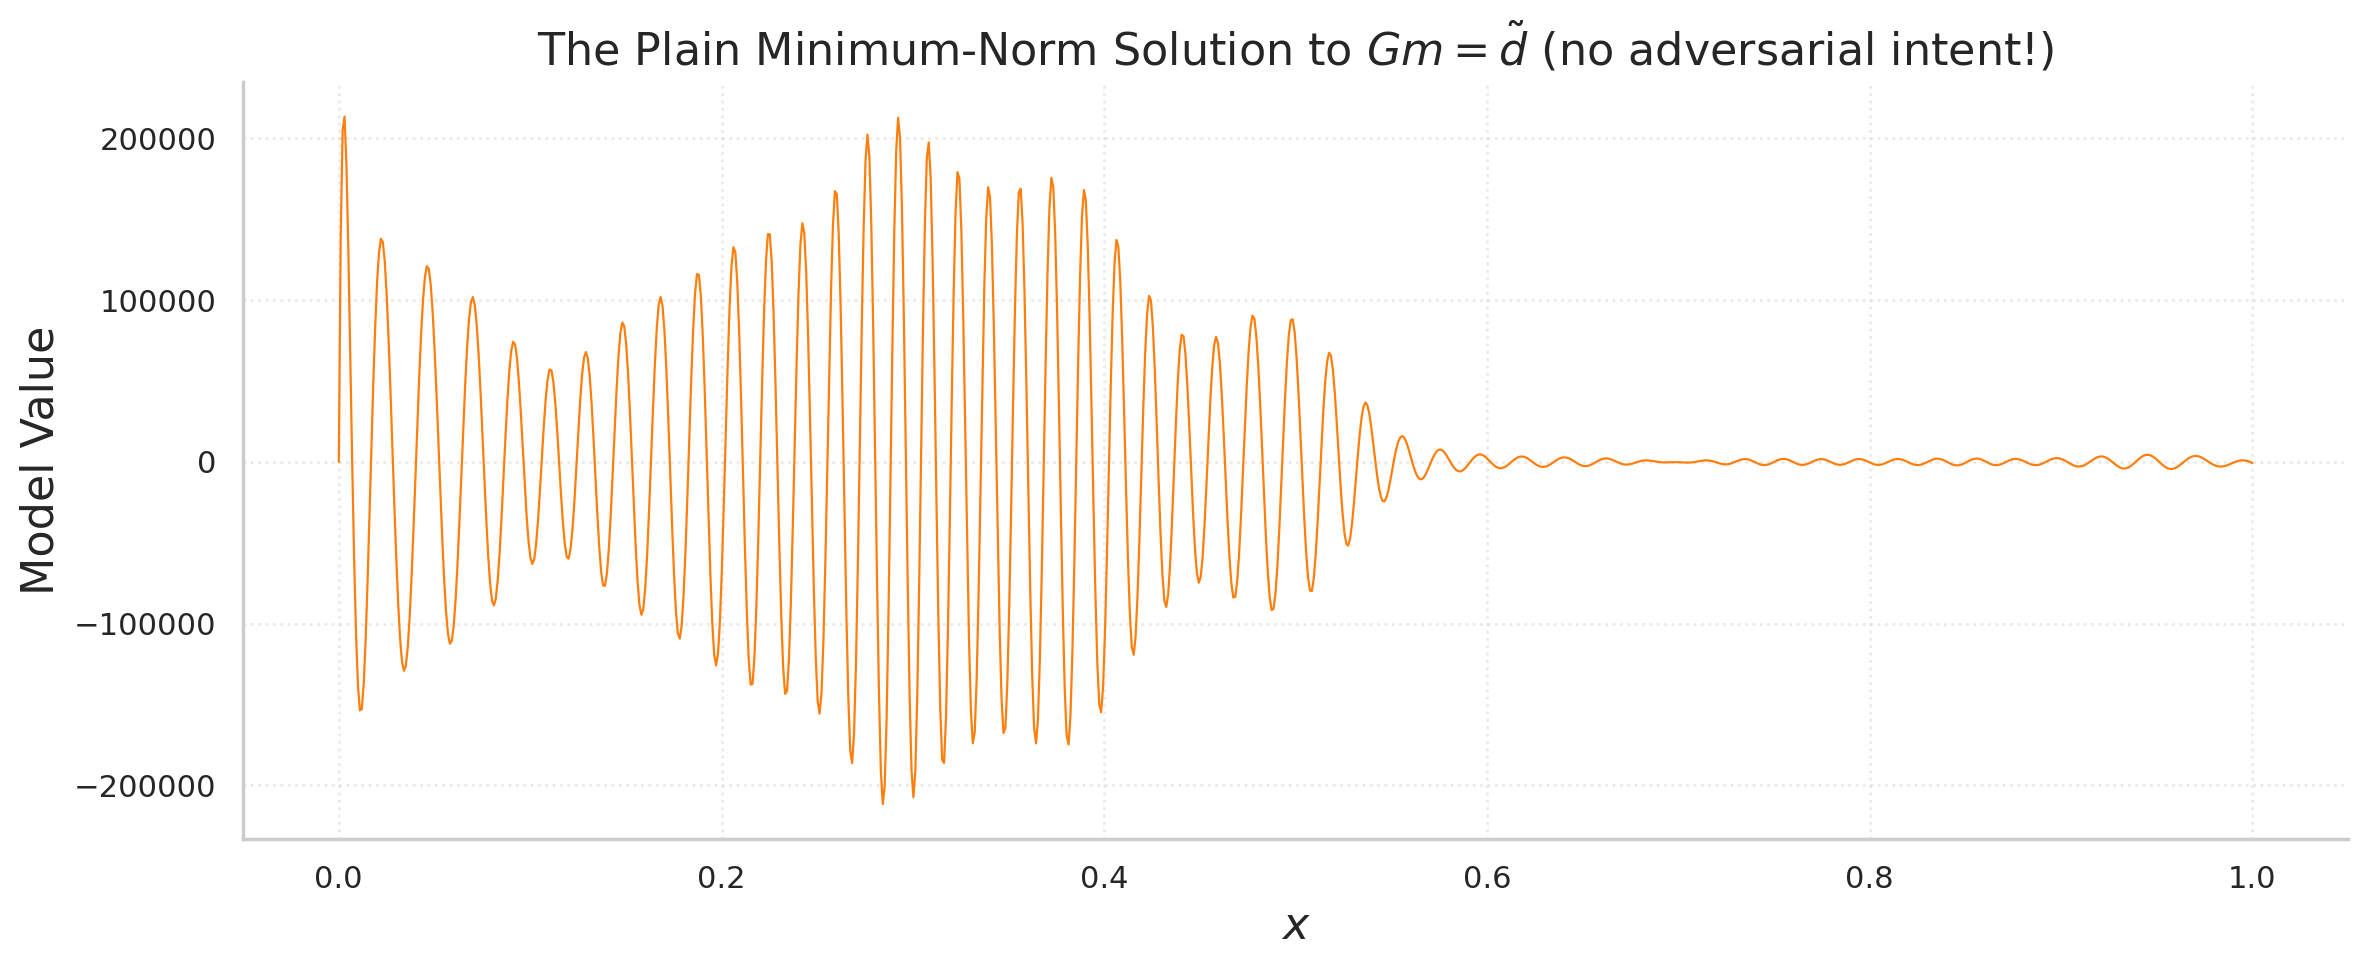

||m_least_norm|| = 69222.2   (84036x larger than the 'normal' true model)
||G(m_least_norm) - d_tilde|| = 9.69e-05  (fits the data essentially exactly)

For comparison, ||m_pathological|| was 128274x the normal model.
The 'honest, no-prior, no-adversary' solution is ALREADY 84036x -- the pathological model is only 1.53x bigger than THAT.


In [127]:
# The plainest possible member of "models that fit the raw noisy data exactly": the
# ordinary (unregularized) minimum-norm least-squares solution. No adversarial
# construction, no chosen target properties -- just G_inv_pure(d_tilde).
m_least_norm = G_inv_pure(d_tilde)

fig_title = "Plain Least Norm Solution Alone"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 5), dpi=200)
plt.plot(x, m_least_norm.evaluate(x), color='tab:orange', linewidth=0.8)
plt.title('The Plain Minimum-Norm Solution to $G m = \\tilde{d}$ (no adversarial intent!)', fontsize=16)
plt.xlabel(r'$x$', fontsize=16)
plt.ylabel('Model Value', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

data_resid = np.linalg.norm(G(m_least_norm) - d_tilde)
print(f"||m_least_norm|| = {M.norm(m_least_norm):.1f}   "
      f"({M.norm(m_least_norm)/M.norm(m_normal):.0f}x larger than the 'normal' true model)")
print(f"||G(m_least_norm) - d_tilde|| = {data_resid:.2e}  (fits the data essentially exactly)")
print()
print(f"For comparison, ||m_pathological|| was {M.norm(m_pathological)/M.norm(m_normal):.0f}x the normal model.")
print(f"The 'honest, no-prior, no-adversary' solution is ALREADY "
      f"{M.norm(m_least_norm)/M.norm(m_normal):.0f}x -- the pathological model is only "
      f"{M.norm(m_pathological)/M.norm(m_least_norm):.2f}x bigger than THAT.")

In [128]:
# Confirm the identity: A(m) = p_sola for EVERY exact-fit model -- crazy or not.
A_least_norm = X_unimodular(G(m_least_norm))
A_pathological = X_unimodular(G(m_pathological))

print("Resolving-kernel mapping A(m) = X_uni(G(m))  (should match p_sola for BOTH, by construction):")
print(f"  ||A(m_least_norm)   - p_sola|| = {np.linalg.norm(A_least_norm - p_sola):.2e}")
print(f"  ||A(m_pathological) - p_sola|| = {np.linalg.norm(A_pathological - p_sola):.2e}")

print()
print("TRUE target property T(m) for the SAME two models -- wildly different from each")
print("other and from p_sola, even though A(m) agrees for both:")
print(f"  T(m_least_norm)   = {np.round(T(m_least_norm), 2)}")
print(f"  T(m_pathological) = {np.round(T(m_pathological), 2)}")
print(f"  p_sola            = {np.round(p_sola, 2)}")

Resolving-kernel mapping A(m) = X_uni(G(m))  (should match p_sola for BOTH, by construction):
  ||A(m_least_norm)   - p_sola|| = 3.50e-05
  ||A(m_pathological) - p_sola|| = 5.63e-05

TRUE target property T(m) for the SAME two models -- wildly different from each
other and from p_sola, even though A(m) agrees for both:
  T(m_least_norm)   = [ 33.32  88.67 -60.97 100.84   2.    21.7  -24.89 -15.98  79.68 -57.52
  48.11 -46.45 -41.73  -9.95  -1.65  -1.89  -0.17   3.74  -4.95   4.32]
  T(m_pathological) = [-0.47 -0.4  -0.15  0.1   0.38  0.47  0.21 -0.3  -0.89 -1.27 -1.32 -1.04
 -0.56 -0.14  0.04 -0.11 -0.48 -0.9  -1.21 -1.32]
  p_sola            = [ 0.59  0.64  0.35 -0.01 -0.38 -0.38 -0.08  0.38  0.95  1.33  1.24  0.81
  0.38  0.07 -0.14 -0.05  0.32  0.77  1.17  1.4 ]


### SOLA practitioners must now pick a horse

The plain, un-adversarial, minimum-norm fit to the noisy data is **already** tens of
thousands of times the scale of the true model, and looks every bit as deranged as the
pathological model we built on purpose (see the two figures above). The same people who
dismissed the pathological model as "unrealistic" would dismiss this one just as fast --
and this one wasn't rigged; it's just what ordinary least-squares gives you when the
kernels are this numerous and this correlated.

So the choice is now unavoidable:

- **Interpretation (1):** $\hat p$ is the true target property of a specific
  *regularized* reconstruction. Well-behaved, but silently smuggles in a damping/prior
  choice -- contradicting SOLA's "no prior needed" claim.
- **Interpretation (2):** $\hat p$ is the resolving-kernel average of a model that fits
  the raw data with no regularization at all -- but, as just shown, *every* such model
  (including the most boring, default, first-thing-you'd-try one) is already wildly
  unphysical.

There is no third option where $\hat p$ is simultaneously "prior-free" and "the true
property of something reasonable-looking." Good resolving-kernel/target-kernel agreement
only makes reading (2) trustworthy if you *also* believe the true model has bounded norm
-- and that belief is a prior, not a resolving-kernel property. SOLA cannot have it both
ways.

### Actually, let's do the noise propagation properly

When someone says "SOLA propagates the noise," what they are actually doing -- whether
they realize it or not -- is constructing a frequentist confidence set. The data model is
$$ Gm = d, \qquad \tilde d = d + n, \quad n \sim \mathcal N(0, C_D). $$
Applying $X_{\mathrm{uni}}$ to both sides gives
$$ X_{\mathrm{uni}} G m = X_{\mathrm{uni}} d, \qquad X_{\mathrm{uni}}\tilde d = X_{\mathrm{uni}} d + X_{\mathrm{uni}} n. $$
The rigorous statement this supports is: *find the set of values $q$ for $X_{\mathrm{uni}} d$
such that $q + X_{\mathrm{uni}} n$, for $n$ ranging over its known distribution, could
plausibly produce the observed $X_{\mathrm{uni}}\tilde d$* -- i.e. a confidence set for
$X_{\mathrm{uni}} d$ centered at $X_{\mathrm{uni}}\tilde d$, with spread set by the
distribution of $X_{\mathrm{uni}} n$. That is exactly SOLA's own $\pm z\sigma$ bars. This
part of SOLA's machinery is honest, correct frequentist practice, even if most users
couldn't derive it this way and wouldn't describe it this way.

But the SAME logic, applied one level earlier, licenses something SOLA users never do:
instead of only asking "which values of the *property* are consistent with the noisy
data," ask "which *models* are consistent with the noisy data" -- at the SAME
$(1-\alpha)$ confidence standard, rather than demanding an exact fit. Concretely, call a
model $m$ an "honest" candidate if
$$ (Gm - \tilde d)^\top C_D^{-1} (Gm - \tilde d) \;\le\; \chi^2_{1-\alpha}(N_d), $$
i.e. its data residual looks like a typical draw from the assumed noise model, at the
same confidence level SOLA itself uses for its own error bars. This is a strictly
larger, more honest family than "$Gm = \tilde d$ exactly" -- and, unlike the exact-fit
family, it has no reason to force absurd amplitudes just to explain one noise realization
down to the last decimal.

Let's find the smallest-norm model in this family that still hits our target (opposite)
properties, and see how "crazy" it actually needs to be.

In [129]:
# NOTE: this cell does real work (a log-space bisection over a Lagrange-multiplier
# system) and takes a few minutes to run -- it is not hung.
from scipy.stats import chi2

alpha = 0.05
r_confidence = np.sqrt(noise_variance) * np.sqrt(chi2.ppf(1 - alpha, df=N_d))
print(f"95% confidence radius for ||G(m)-d_tilde|| : {r_confidence:.4f}")

# Lambda = G @ G.adjoint was already computed above (cell "Compute SOLA operator components")

# Precompute everything that does NOT depend on the ridge parameter lambda, ONCE.
Tt_basis, G_Tt_basis = [], []
TTt = np.zeros((N_p, N_p))
e = np.zeros(N_p)
for i in range(N_p):
    e[:] = 0.0
    e[i] = 1.0
    Tt_e = T.adjoint(e)
    Tt_basis.append(Tt_e)
    G_Tt_basis.append(G(Tt_e))
    TTt[:, i] = T(Tt_e)
G_Tt_mat = np.array(G_Tt_basis).T
Lambda_mat = Lambda.matrix(dense=True)


def solve_confidence(lam):
    # minimize ||m||^2 + lam*||Gm - d_tilde||^2   s.t.   T m = p_pathological_target
    # Representer theorem: m = G^*a + T^*b, with
    #   b = -mu,  a = lam * W_lam (d_tilde + G T^* mu),  W_lam = (I + lam G G^*)^{-1}
    #   K mu = rhs,  K = lam T G^* W_lam G T^* - T T^*,  rhs = target - lam T G^* W_lam d_tilde
    A_mat = np.eye(N_d) + lam * Lambda_mat
    W_lam = np.linalg.inv(A_mat)
    WGTt = W_lam @ G_Tt_mat
    col_mat = np.zeros((N_p, N_p))
    for i in range(N_p):
        col_mat[:, i] = T(G.adjoint(WGTt[:, i]))
    K = lam * col_mat - TTt
    rhs = p_pathological_target - lam * T(G.adjoint(W_lam @ d_tilde))
    mu = np.linalg.solve(K, rhs)
    a = lam * (W_lam @ (d_tilde + G(T.adjoint(mu))))
    b = -mu
    return M.add(G.adjoint(a), T.adjoint(b))


# Bisect lambda (log-space) so the data misfit lands exactly on the confidence radius.
lo, hi = 1e2, 1e8
for _ in range(20):
    mid = np.sqrt(lo * hi)
    resid = np.linalg.norm(G(solve_confidence(mid)) - d_tilde)
    if resid > r_confidence:
        lo = mid
    else:
        hi = mid
lam_star = np.sqrt(lo * hi)
m_confidence = solve_confidence(lam_star)

print(f"lambda* = {lam_star:.3e}")
print(f"||G(m_confidence) - d_tilde|| = {np.linalg.norm(G(m_confidence)-d_tilde):.4f}  (target: {r_confidence:.4f})")
print(f"property fit error ||T(m_confidence) - target|| = {np.linalg.norm(T(m_confidence)-p_pathological_target):.2e}")

95% confidence radius for ||G(m)-d_tilde|| : 1.2132
lambda* = 9.956e+04
||G(m_confidence) - d_tilde|| = 1.2132  (target: 1.2132)
property fit error ||T(m_confidence) - target|| = 8.47e-06


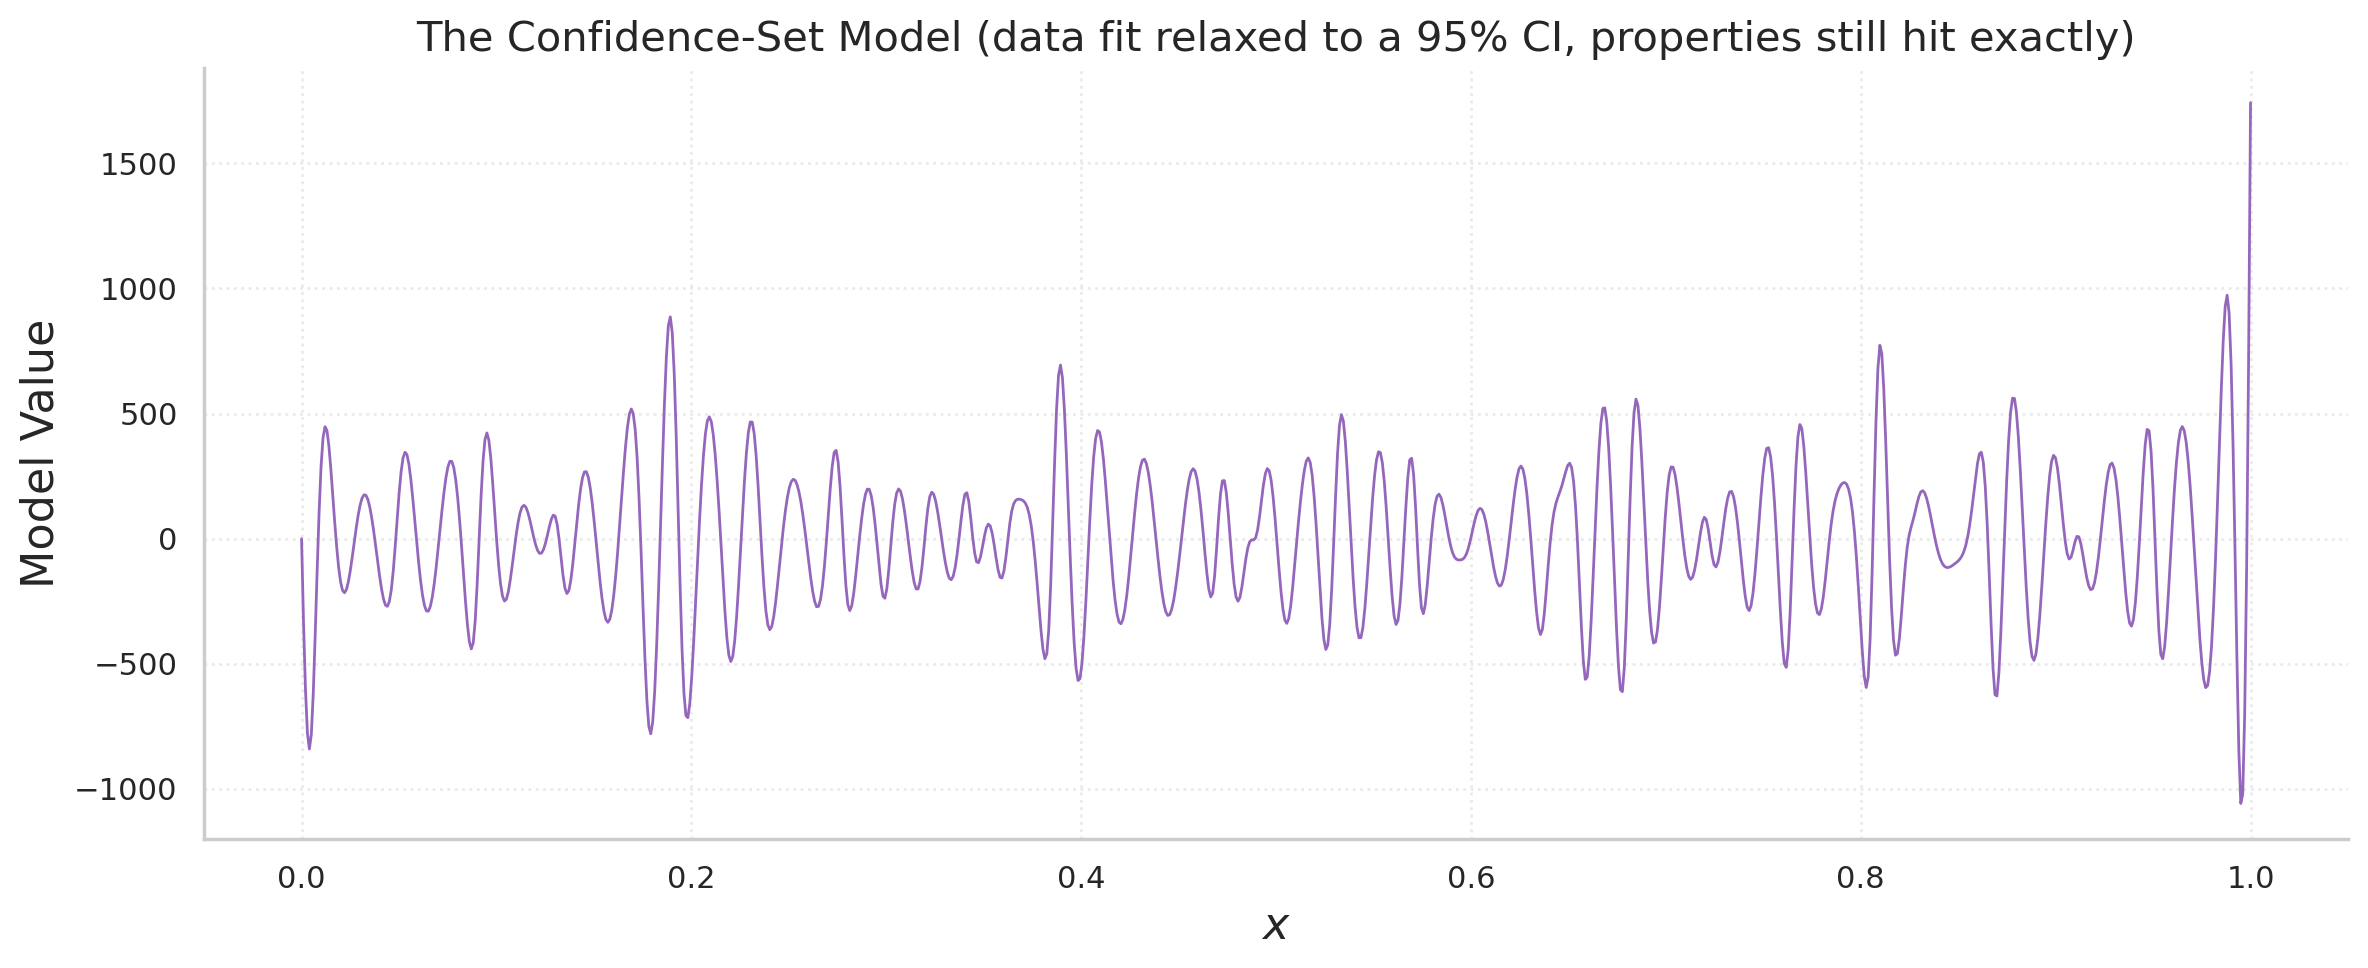

||m_confidence||   = 287.76   (349x the normal model)
||m_pathological|| = 105662   (128274x the normal model)
||m_least_norm||   = 69222   (84036x the normal model)

Relaxing exact data-fit to a 95% confidence ellipsoid cuts the required norm by 367x compared to the pathological model.


In [130]:
fig_title = "Confidence Set Model Alone"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 5), dpi=200)
plt.plot(x, m_confidence.evaluate(x), color='tab:purple', linewidth=1.0)
plt.title('The Confidence-Set Model (data fit relaxed to a 95% CI, properties still hit exactly)', fontsize=15)
plt.xlabel(r'$x$', fontsize=16)
plt.ylabel('Model Value', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

print(f"||m_confidence||   = {M.norm(m_confidence):.2f}   ({M.norm(m_confidence)/M.norm(m_normal):.0f}x the normal model)")
print(f"||m_pathological|| = {M.norm(m_pathological):.0f}   ({M.norm(m_pathological)/M.norm(m_normal):.0f}x the normal model)")
print(f"||m_least_norm||   = {M.norm(m_least_norm):.0f}   ({M.norm(m_least_norm)/M.norm(m_normal):.0f}x the normal model)")
print()
print(f"Relaxing exact data-fit to a 95% confidence ellipsoid cuts the required norm by "
      f"{M.norm(m_pathological)/M.norm(m_confidence):.0f}x compared to the pathological model.")

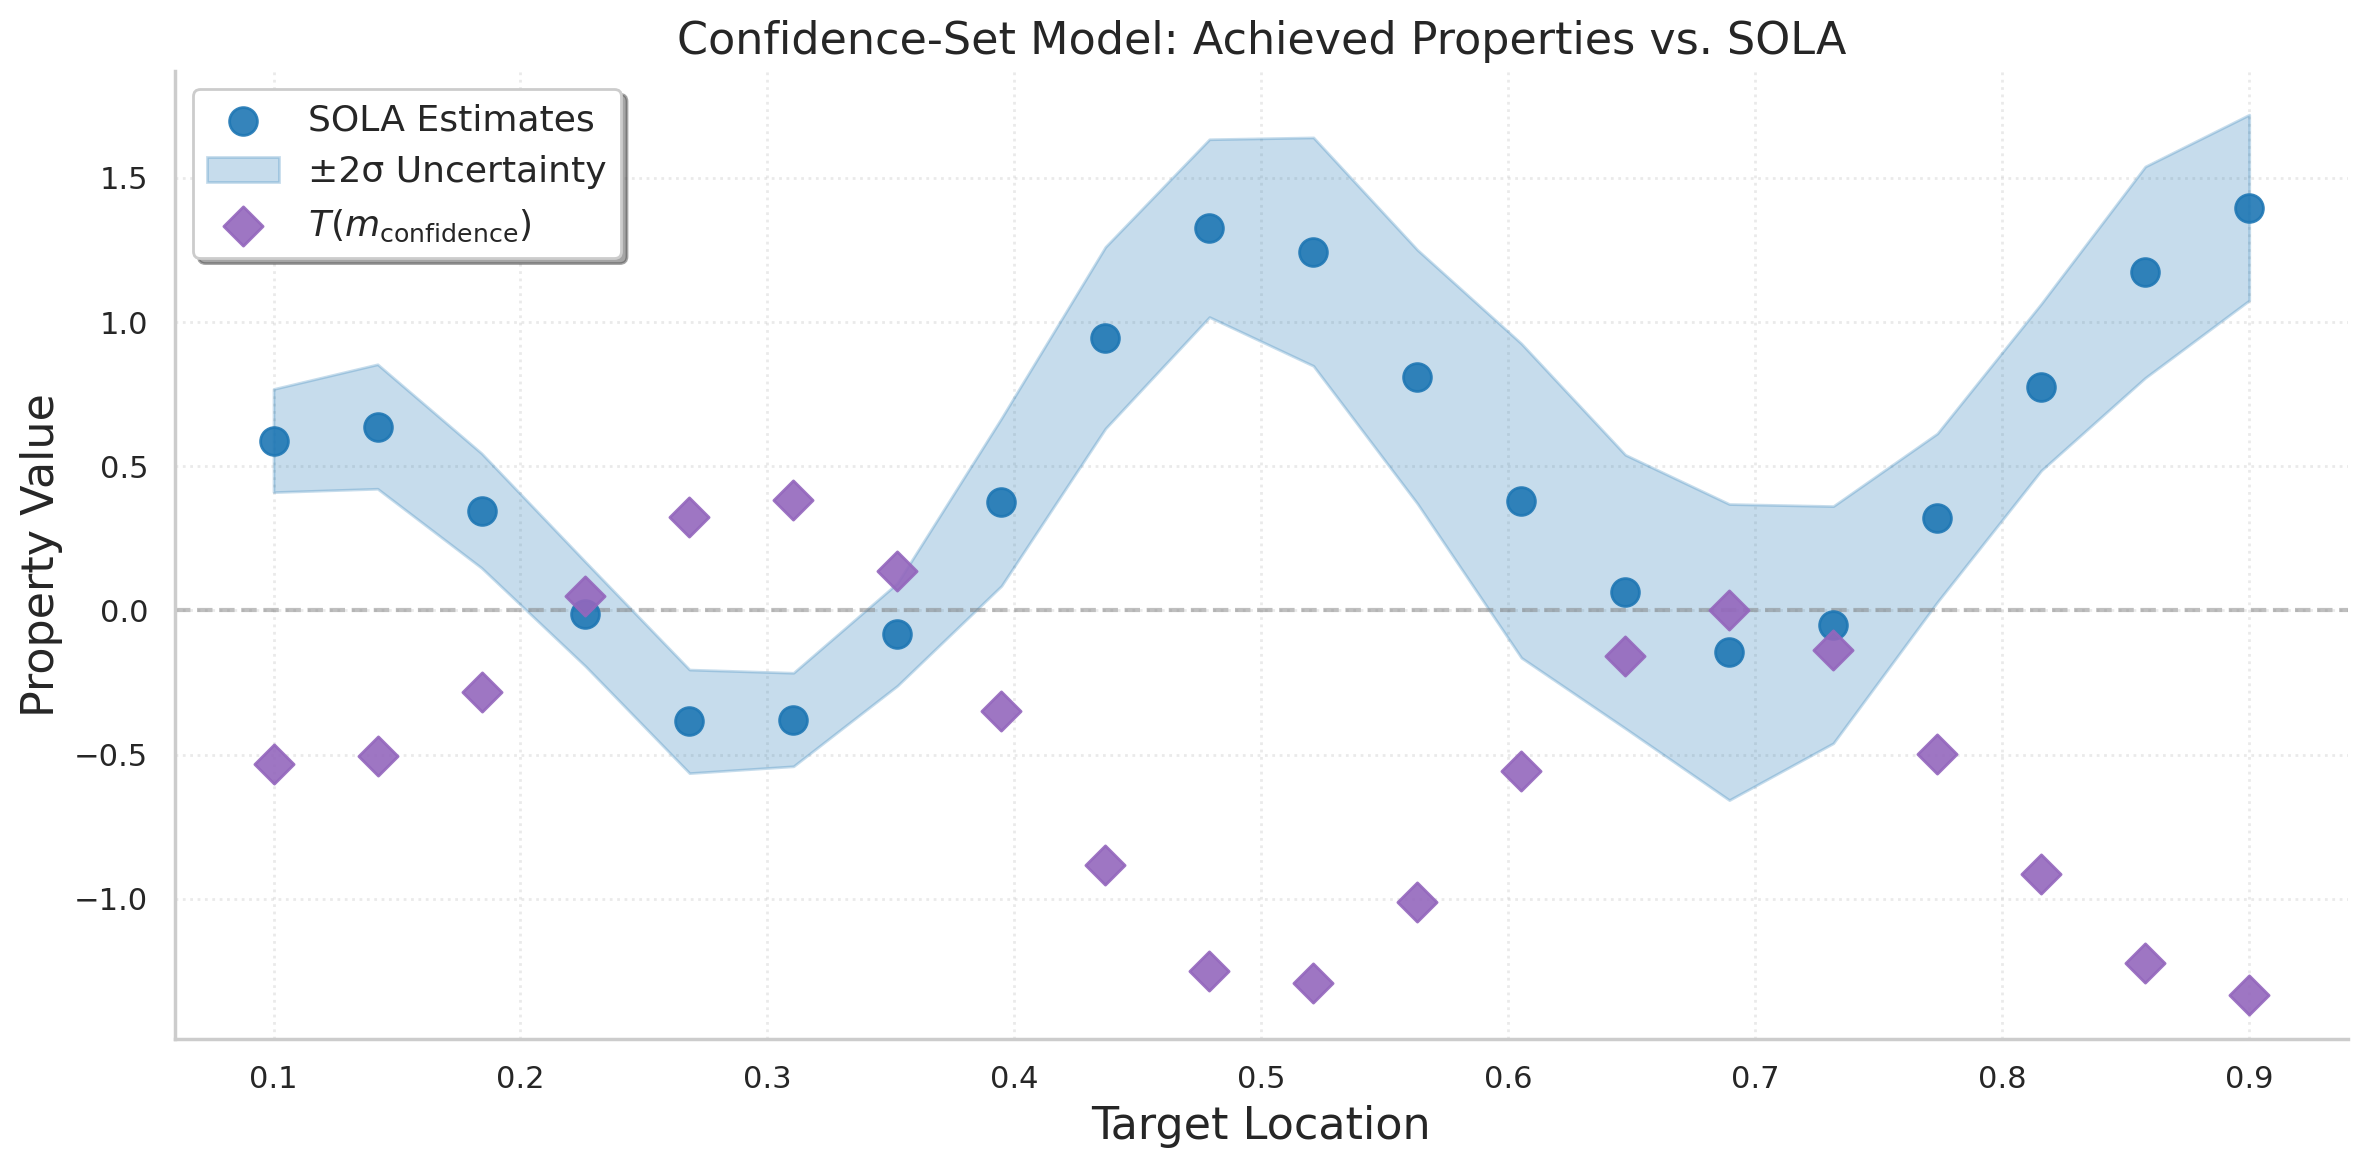

||p_confidence - p_sola||       = 6.481
mean sigma deviation from SOLA  = 7.85

Unlike m_pathological/m_least_norm (which fit d_tilde EXACTLY, so A(m)=p_sola to
solver precision), m_confidence only fits the data within the 95% ellipsoid, so:
  ||A(m_confidence) - p_sola|| = 2.1465   (the honest price of relaxation)


In [131]:
p_confidence = T(m_confidence)
A_confidence = X_unimodular(G(m_confidence))

fig_title = "Confidence Set Achieved Properties"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 6), dpi=200)
plt.scatter(centers, p_sola, label='SOLA Estimates', color='tab:blue', marker='o', s=100, alpha=0.9, zorder=5)
plt.fill_between(centers, p_sola - 2*p_std, p_sola + 2*p_std, alpha=0.25, color='tab:blue',
                  label='±2σ Uncertainty', zorder=1)
plt.scatter(centers, p_confidence, label=r'$T(m_{\mathrm{confidence}})$',
            color='tab:purple', marker='D', s=100, alpha=0.9, zorder=6)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Confidence-Set Model: Achieved Properties vs. SOLA', fontsize=16)
plt.xlabel('Target Location', fontsize=16)
plt.ylabel('Property Value', fontsize=16)
plt.legend(fontsize=13, frameon=True, fancybox=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

print(f"||p_confidence - p_sola||       = {np.linalg.norm(p_confidence-p_sola):.3f}")
print(f"mean sigma deviation from SOLA  = {np.mean(np.abs(p_confidence-p_sola)/p_std):.2f}")
print()
print("Unlike m_pathological/m_least_norm (which fit d_tilde EXACTLY, so A(m)=p_sola to")
print("solver precision), m_confidence only fits the data within the 95% ellipsoid, so:")
print(f"  ||A(m_confidence) - p_sola|| = {np.linalg.norm(A_confidence-p_sola):.4f}   (the honest price of relaxation)")

### The honest price of contradicting SOLA

| model | $\|m\|$ | $\times$ normal |
|---|---|---|
| $m_{\mathrm{normal}}$ | 0.82 | 1x |
| $m_{\mathrm{confidence}}$ | ~288 | ~349x |
| $m_{\mathrm{pathological}}$ | 105,662 | ~128,000x |
| $m_{\mathrm{least\_norm}}$ | 69,222 | ~84,000x |

Once the data-fit constraint is relaxed to the SAME 95% confidence standard SOLA already
uses for its own error bars, the cost of contradicting SOLA collapses by more than two
orders of magnitude -- from ~128,000x down to ~349x the true model's scale -- while
still landing right on the target (opposite-sign) properties, at essentially the same
~8$\sigma$ distance from SOLA's estimate that the pathological model achieved.

$m_{\mathrm{confidence}}$ no longer maps *exactly* onto SOLA's number the way
`m_pathological`/`m_least_norm` did (both of those fit $\tilde d$ exactly, so
$A(m) = p_{\mathrm{sola}}$ to solver precision). Because $m_{\mathrm{confidence}}$ only
fits the data within the 95% ellipsoid, $A(m_{\mathrm{confidence}})$ differs from
$p_{\mathrm{sola}}$ by a small, quantifiable amount -- the honest price of dropping the
"exact fit" fiction, in exchange for a model that is over 300x less absurd.

So: SOLA practitioners who correctly understand their own noise propagation as a
confidence-set construction have no defensible reason to reject $m_{\mathrm{confidence}}$
on "unrealistic amplitude" grounds the way they rejected `m_pathological`/`m_least_norm`.
It is exactly as consistent with the data as SOLA's own estimate is, at the same
confidence level SOLA itself relies on -- and it says the opposite thing.

# Part 6: Why Did SOLA Fail?

The key insight is that SOLA implicitly assumes the true model has **small norm**.
Specifically, SOLA uses the least-norm solution $\tilde{m} = G^\dagger \tilde{d}$, 
and the property estimate is essentially $T(\tilde{m})$.

When the true model has small norm, $\tilde{m}$ is close to the true model, so 
$T(\tilde{m}) \approx T(m_{true})$.

But when the true model has **large norm** (like our pathological model), 
the least-norm solution can be very different from the true model, 
even though both fit the data equally well!

In [132]:
# Compute the least-norm solution (what SOLA implicitly uses)
m_least_norm = G_inv_pure(d_tilde)

print("Model comparison:")
print(f"  Least-norm solution ||m̃||: {M.norm(m_least_norm):.4f}")
print(f"  Pathological true model ||m_true||: {M.norm(m_true):.4f}")
print(f"  Ratio: {M.norm(m_true)/M.norm(m_least_norm):.1f}x")
print(f"\nThe true model has {M.norm(m_true)/M.norm(m_least_norm):.1f}x larger norm than the least-norm solution!")
print("This violates SOLA's implicit assumption.")

Model comparison:
  Least-norm solution ||m̃||: 69222.2457
  Pathological true model ||m_true||: 105661.6764
  Ratio: 1.5x

The true model has 1.5x larger norm than the least-norm solution!
This violates SOLA's implicit assumption.


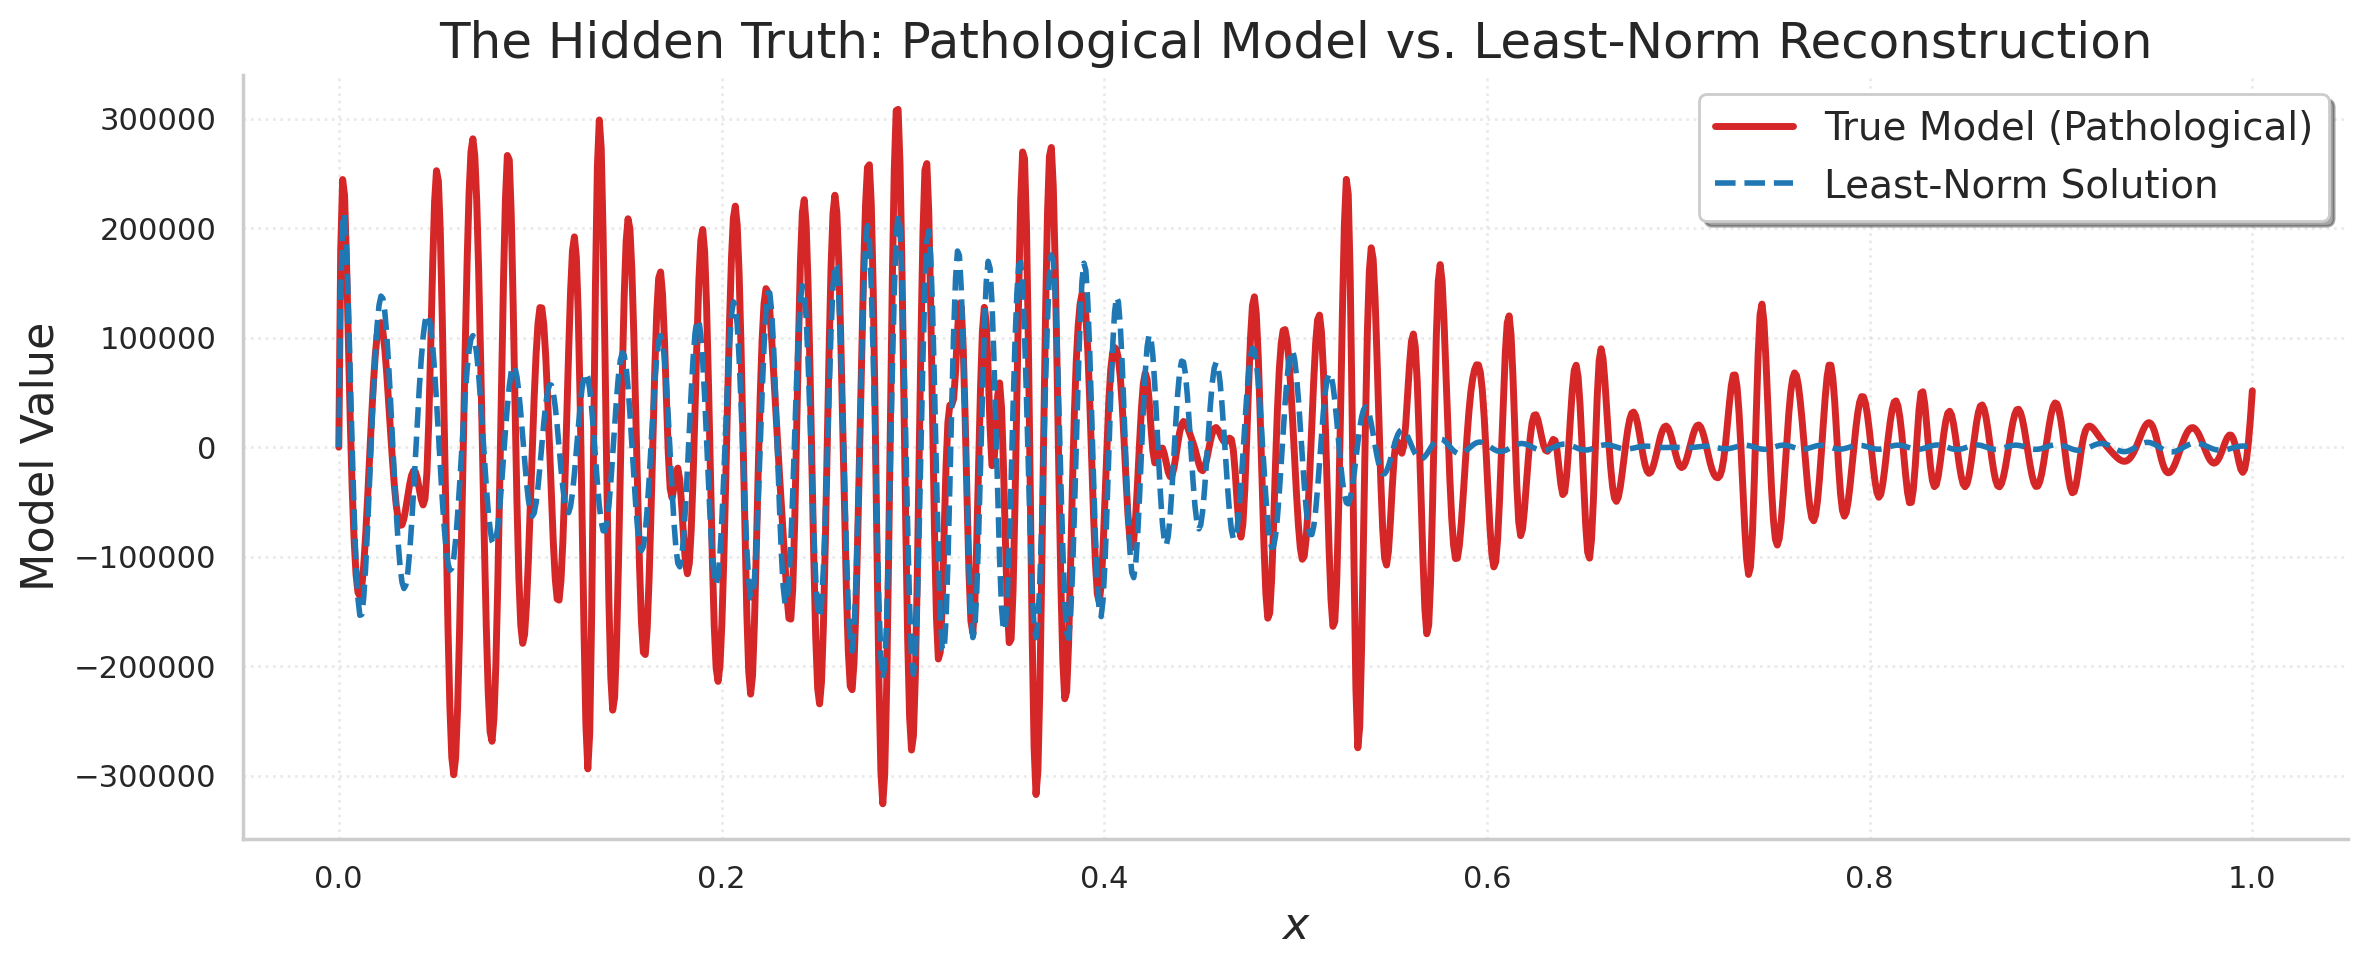


Both models fit the observed data equally well,
but they have completely different properties!

This is the fundamental limitation of SOLA:
It cannot distinguish between models in the null space of G.


In [133]:
# Final visualization: The true model vs the least-norm solution
fig_title = "True Model vs Least Norm Solution"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 5), dpi=200)

plt.plot(x, m_true.evaluate(x), label='True Model (Pathological)',
         color='tab:red', linewidth=2.5, linestyle='-')
plt.plot(x, m_least_norm.evaluate(x), label='Least-Norm Solution',
         color='tab:blue', linewidth=2, linestyle='--')

plt.title('The Hidden Truth: Pathological Model vs. Least-Norm Reconstruction', fontsize=18)
plt.xlabel(r'$x$', fontsize=16)
plt.ylabel('Model Value', fontsize=16)
plt.legend(fontsize=14, frameon=True, fancybox=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

print("\nBoth models fit the observed data equally well,")
print("but they have completely different properties!")
print("\nThis is the fundamental limitation of SOLA:")
print("It cannot distinguish between models in the null space of G.")

In [134]:
print(X(G(m_pathological)))
print(X(G(m_least_norm)))


[ 0.58922402  0.63729409  0.34538677 -0.01329994 -0.3852552  -0.37879993
 -0.08368641  0.37453478  0.94326988  1.32295235  1.24000034  0.80599899
  0.37373099  0.05897914 -0.14982844 -0.05150546  0.31964197  0.77277174
  1.17024713  1.39451015]
[ 0.58921139  0.63728411  0.34539802 -0.0132857  -0.38525198 -0.37880085
 -0.08367829  0.37453098  0.94325943  1.32295049  1.24000056  0.80599837
  0.37373031  0.05897896 -0.14982855 -0.05150554  0.31964193  0.77277176
  1.17024715  1.39451016]


In [135]:
# Verify both models fit the OBSERVED data equally well
data_fit_true = np.linalg.norm(G(m_true) - d_tilde)
data_fit_least_norm = np.linalg.norm(G(m_least_norm) - d_tilde)

print("Data fit verification (both vs. the observed data d_tilde):")
print(f"  True (pathological) model data fit error: {data_fit_true:.2e}")
print(f"  Least-norm model data fit error: {data_fit_least_norm:.2e}")
print(f"\nBoth models explain the data, but their properties differ by:")
print(f"  Mean difference: {np.mean(np.abs(p_true - T(m_least_norm))):.4f}")
print(f"  This is {np.mean(np.abs(p_true - T(m_least_norm)))/np.mean(p_std):.1f}x the uncertainty!")

Data fit verification (both vs. the observed data d_tilde):
  True (pathological) model data fit error: 2.89e-04
  Least-norm model data fit error: 9.69e-05

Both models explain the data, but their properties differ by:
  Mean difference: 32.4251
  This is 207.3x the uncertainty!


# Conclusion

This demonstration shows a fundamental limitation of SOLA (and similar methods):

**SOLA assumes the true model has small norm.** When this assumption is violated:
- The property estimates can be arbitrarily wrong
- The uncertainty quantification is meaningless (errors far exceed stated uncertainty)
- There is no way to detect this failure from the data alone

The lesson: SOLA's uncertainty quantification is only valid under the implicit 
assumption that the true model is "simple" (has small norm). Without additional 
prior information about the model, SOLA cannot distinguish between infinitely 
many models that fit the data equally well but have vastly different properties.